# 📂 Multi-Location UWB Dataset Loading & Schema Validation

## 📌 Objective
This section focuses on loading UWB dataset files from **23 different locations** and ensuring **feature consistency** across all datasets before model training.

---

## 📊 Dataset Structure
- Each location is stored as a separate CSV file:
  - Format: `exportloc{n}IQ.csv` where `n = 1 → 23`
- Each file contains signal and CIR-related features collected from UWB devices

---

## ⚙️ Processing Steps

### 1️⃣ Load All Location Files
- Iterate through all 23 locations
- Read available CSV files into memory
- Store them in a dictionary:
  - **Key** → Location ID  
  - **Value** → Corresponding DataFrame

---

### 2️⃣ Identify Common Features
- Extract column names from all datasets
- Compute the **intersection of features**
- Ensures that only features present in *every location* are used

✔️ This step is critical to:
- Avoid training issues due to missing columns
- Maintain a consistent feature space across environments

---

### 3️⃣ Data Type Consistency Check
- For each common feature:
  - Compare data types across all locations
- Detect columns where dtype differs between datasets

⚠️ Why this matters:
- Inconsistent data types can break training pipelines
- May lead to incorrect parsing (e.g., numeric vs string)
- Needs correction before merging datasets

---

## 📈 Outputs
- Total number of common features across all locations
- List of consistent feature names
- Identification of columns with **inconsistent data types**
  - Includes which locations have which dtype

---

## 🧠 Key Insight
Even if column names match across datasets, **data types may differ**, which introduces hidden bugs.  
This step ensures the dataset is **structurally aligned and safe for downstream processing**.

---

## 🚀 Next Step
- Fix inconsistent data types
- Merge datasets
- Proceed to feature engineering and model training


In [3]:
import pandas as pd
import os

DATA_DIR = "."
dfs = {}  # key = location id, value = DataFrame

# Load all CSVs first
for loc in range(1, 24):
    filename = f"exportloc{loc}IQ.csv"
    filepath = os.path.join(DATA_DIR, filename)

    if os.path.exists(filepath):
        dfs[loc] = pd.read_csv(filepath)
    else:
        print(f"Missing file: {filename}")

# Initialize common columns from first available location
first_loc = next(iter(dfs))
common_columns = set(dfs[first_loc].columns)

# Find intersection
for loc in dfs:
    common_columns &= set(dfs[loc].columns)

common_columns = sorted(common_columns)

print("Number of common features:", len(common_columns))
print(common_columns)

Number of common features: 1057
['CIR0', 'CIR1', 'CIR10', 'CIR100', 'CIR1000', 'CIR1001', 'CIR1002', 'CIR1003', 'CIR1004', 'CIR1005', 'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR101', 'CIR1010', 'CIR1011', 'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015', 'CIR102', 'CIR103', 'CIR104', 'CIR105', 'CIR106', 'CIR107', 'CIR108', 'CIR109', 'CIR11', 'CIR110', 'CIR111', 'CIR112', 'CIR113', 'CIR114', 'CIR115', 'CIR116', 'CIR117', 'CIR118', 'CIR119', 'CIR12', 'CIR120', 'CIR121', 'CIR122', 'CIR123', 'CIR124', 'CIR125', 'CIR126', 'CIR127', 'CIR128', 'CIR129', 'CIR13', 'CIR130', 'CIR131', 'CIR132', 'CIR133', 'CIR134', 'CIR135', 'CIR136', 'CIR137', 'CIR138', 'CIR139', 'CIR14', 'CIR140', 'CIR141', 'CIR142', 'CIR143', 'CIR144', 'CIR145', 'CIR146', 'CIR147', 'CIR148', 'CIR149', 'CIR15', 'CIR150', 'CIR151', 'CIR152', 'CIR153', 'CIR154', 'CIR155', 'CIR156', 'CIR157', 'CIR158', 'CIR159', 'CIR16', 'CIR160', 'CIR161', 'CIR162', 'CIR163', 'CIR164', 'CIR165', 'CIR166', 'CIR167', 'CIR168', 'CIR169', 'CIR17', 'CI

In [2]:
import pandas as pd

dtype_map = {}  # column -> {dtype: [locations]}

for loc, df in dfs.items():
    for col in common_columns:
        dtype = df[col].dtype
        dtype_map.setdefault(col, {}).setdefault(dtype, []).append(loc)

# Find columns with inconsistent dtypes
inconsistent = {
    col: types
    for col, types in dtype_map.items()
    if len(types) > 1
}

print("Number of columns with inconsistent dtypes:", len(inconsistent))

# Show first few problematic columns
for col, types in list(inconsistent.items())[:10]:
    print(f"\nColumn: {col}")
    for dtype, locs in types.items():
        print(f"  {dtype}: locations {locs}")

Number of columns with inconsistent dtypes: 0


# 📡 Dual-Loss Autoencoder for UWB Ranging Error Correction

## 📌 Objective
This section implements a **dual-loss autoencoder model** for predicting and correcting UWB ranging errors using raw **Channel Impulse Response (CIR)** data.

The approach is inspired by the paper:  
**"Edge Inference for UWB Ranging Error Correction Using Autoencoders"**

---

## 🧠 Core Idea
Instead of only predicting error, the model **learns two tasks simultaneously**:
1. **Reconstruct the CIR signal** (unsupervised learning)
2. **Predict ranging error** (supervised learning)

This improves feature learning and generalization.

---

## ⚙️ Data Processing Pipeline

### 1️⃣ CIR Parsing & Alignment
- Each sample contains **1016 complex CIR values**
- Convert strings → complex numbers
- Split into:
  - Real part
  - Imaginary part

### 2️⃣ First Path Alignment
- Use `fpindex` (first path index)
- Convert using:
  ```
  fpindex_actual = fpindex // 64
  ```
- Extract a **fixed window (500 samples)** centered around fpindex

✔️ This ensures:
- Model focuses on the most important signal region
- Consistent input representation across samples

---

### 3️⃣ Input Representation
Final input shape:
```
(500, 2)
```
- 500 time samples
- 2 channels → (real, imaginary)

---

### 4️⃣ Dataset Aggregation
- Process all **23 locations**
- Concatenate into a single dataset:
  - `X` → CIR segments
  - `y` → ranging error

---

### 5️⃣ Train / Validation / Test Split
- Random split:
  - 80% Train
  - 10% Validation
  - 10% Test

---

### 6️⃣ Normalization
- Compute **mean & std from training set only**
- Apply normalization to all splits

✔️ Prevents data leakage

---

## 🏗️ Model Architecture

### 🔹 Encoder
- Convolutional layers extract spatial features from CIR
- Reduces input to a **compact latent representation**

### 🔹 Latent Space
- Learned feature representation of CIR
- Shared between:
  - Decoder
  - Predictor

---

### 🔹 Decoder (Reconstruction Task)
- Reconstructs original CIR signal
- Helps model learn meaningful signal structure

---

### 🔹 Predictor (Error Estimation)
- Fully connected network on latent features
- Outputs:
```
Predicted ranging error
```

---

## 🎯 Dual-Loss Function

The model is trained using **two losses simultaneously**:

- Reconstruction Loss:
```
L_recon = MAE(CIR_reconstructed, CIR_original)
```

- Prediction Loss:
```
L_pred = MAE(error_predicted, error_true)
```

### ✅ Final Loss:
```
L_total = L_recon + L_pred
```

✔️ This enforces:
- Good signal representation
- Accurate error prediction

---

## 🚀 Training Strategy
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- Epochs: up to 500
- Early Stopping:
  - Patience = 25
  - Restore best weights

---

## 📊 Evaluation

### Metrics:
- Reconstruction MAE
- Prediction MAE

### Error Correction:
```
Corrected Error = True Error − Predicted Error
```

---

## 📈 Key Insight
By jointly learning **signal reconstruction + error prediction**,  
the model captures deeper patterns in CIR data compared to standard DNNs.

This leads to:
- Better generalization
- Improved robustness in NLOS conditions
- Lower ranging error

---




In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. Assume `dfs` dictionary is already loaded (keys: location id)
# ------------------------------------------------------------

# ------------------------------------------------------------
# 2. Function to parse complex CIR, align, and clip fpindex
# ------------------------------------------------------------
def parse_and_align(df, window_size=500):
    cir_cols = [f'CIR{i}' for i in range(1016)]
    n_samples = len(df)
    half = window_size // 2
    X = np.zeros((n_samples, window_size, 2), dtype=np.float32)
    y = df['error'].values.astype(np.float32)
    
    # Debug: show fpindex range after conversion
    fp_raw = df['fpindex'].values
    fp_converted = (fp_raw // 64).astype(int)
    print(f"  fpindex raw: min={fp_raw.min()}, max={fp_raw.max()}, mean={fp_raw.mean():.1f}")
    print(f"  fpindex //64: min={fp_converted.min()}, max={fp_converted.max()}, mean={fp_converted.mean():.1f}")
    
    for i, row in tqdm(df.iterrows(), total=n_samples, desc="  Processing rows"):
        # Convert fpindex to actual sample index
        fp = int(float(row['fpindex']) // 64)
        fp = np.clip(fp, 0, 1015)   # still clip for safety
        
        # Convert the 1016 complex strings to a numpy array
        complex_vals = [complex(row[col]) for col in cir_cols]
        cir = np.array(complex_vals)
        cir_stacked = np.stack([cir.real, cir.imag], axis=-1)
        
        start = fp - half
        end = fp + half
        start_clip = max(0, start)
        end_clip = min(1016, end)
        segment = cir_stacked[start_clip:end_clip]
        
        if segment.shape[0] < window_size:
            pad_left = max(0, -start)
            pad_right = window_size - segment.shape[0] - pad_left
            segment = np.pad(segment, ((pad_left, pad_right), (0, 0)), mode='constant')
        
        X[i] = segment
    
    return X, y

# ------------------------------------------------------------
# 3. Apply to all locations and concatenate
# ------------------------------------------------------------
X_list, y_list = [], []
for loc, df in dfs.items():
    print(f"\nProcessing location {loc} ...")
    X_loc, y_loc = parse_and_align(df)
    X_list.append(X_loc)
    y_list.append(y_loc)

X = np.concatenate(X_list, axis=0)   # (total_samples, 500, 2)
y = np.concatenate(y_list, axis=0)   # (total_samples,)

print(f"\nTotal samples: {X.shape[0]}")
print(f"Input shape: {X.shape}")

# ------------------------------------------------------------
# 4. Train/Validation/Test split (random 80/10/10)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ------------------------------------------------------------
# 5. Normalize using global mean/std from training set
# ------------------------------------------------------------
mean = X_train.mean(axis=(0, 1), keepdims=True)   # shape (1,1,2)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# ------------------------------------------------------------
# 6. Build the dual-loss autoencoder (AEP)
# ------------------------------------------------------------
def build_dual_loss_aep(input_shape=(500, 2, 1)):
    inputs = layers.Input(shape=input_shape, name='input_cir')
    
    # Encoder
    x = layers.Conv2D(16, (4, 2), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, (4, 1), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 1))(x)                     # (250,2,32)
    x = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(x)
    x = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(x)
    latent = layers.Conv2D(1, (2, 2), activation='relu', padding='same', name='latent')(x)  # (250,2,1)
    
    # Flatten latent for predictor
    latent_flat = layers.Flatten()(latent)   # 500
    
    # Decoder
    d = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(latent)
    d = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(d)
    d = layers.UpSampling2D((2, 1))(d)        # back to (500,2,64)
    d = layers.Conv2D(32, (4, 1), activation='relu', padding='same')(d)
    decoded = layers.Conv2D(1, (1, 1), activation='linear', padding='same', name='decoded')(d)  # (500,2,1)
    
    # Predictor (MLP on top of latent_flat)
    p = layers.Dense(75, activation='relu')(latent_flat)
    p = layers.BatchNormalization()(p)
    p = layers.Dropout(0.15)(p)
    p = layers.Dense(25, activation='relu')(p)
    p = layers.BatchNormalization()(p)
    p = layers.Dense(8, activation='relu')(p)
    prediction = layers.Dense(1, name='prediction')(p)
    
    model = Model(inputs=inputs, outputs=[decoded, prediction])
    return model

model = build_dual_loss_aep()
model.summary()   # Should show ~33k parameters

# ------------------------------------------------------------
# 7. Compile the model
# ------------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'decoded': 'mae',
        'prediction': 'mae'
    },
    loss_weights={
        'decoded': 1.0,
        'prediction': 1.0
    },
    metrics={
        'decoded': ['mae'],
        'prediction': ['mae']
    }
)

# ------------------------------------------------------------
# 8. Prepare targets for training
# ------------------------------------------------------------
train_targets = {
    'decoded': X_train,        # reconstruction target = input
    'prediction': y_train
}
val_targets = {
    'decoded': X_val,
    'prediction': y_val
}

# ------------------------------------------------------------
# 9. Train with early stopping
# ------------------------------------------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history = model.fit(
    X_train, train_targets,
    validation_data=(X_val, val_targets),
    epochs=500,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------------------
# 10. Evaluate on test set
# ------------------------------------------------------------
results = model.evaluate(X_test, {'decoded': X_test, 'prediction': y_test})
print(f"\nTest reconstruction MAE: {results[3]:.3f}")
print(f"Test prediction MAE: {results[4]:.3f}")

# ------------------------------------------------------------
# 11. Compute corrected error
# ------------------------------------------------------------
y_pred = model.predict(X_test)[1].flatten()   # prediction output
new_error = y_test - y_pred                    # residual error after correction

print(f"\nOriginal error MAE (test): {np.abs(y_test).mean():.3f} mm")
print(f"Corrected error MAE (test): {np.abs(new_error).mean():.3f} mm")

2026-04-30 05:30:36.504687: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Processing location 1 ...
  fpindex raw: min=45593.0, max=54321.0, mean=47673.8
  fpindex //64: min=712, max=848, mean=744.5


  Processing rows: 100%|██████████| 1598/1598 [00:03<00:00, 455.15it/s]



Processing location 2 ...
  fpindex raw: min=46893.0, max=50439.0, mean=47769.2
  fpindex //64: min=732, max=788, mean=746.0


  Processing rows: 100%|██████████| 1250/1250 [00:02<00:00, 460.06it/s]


...

646/646 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - decoded_loss: 0.2560 - decoded_mae: 0.2560 - loss: 203.6660 - prediction_loss: 203.4100 - prediction_mae: 203.4100

2026-04-30 05:32:10.718039: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 05:32:11.434065: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_274', 8 bytes spill stores, 8 bytes spill loads



646/646 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - decoded_loss: 0.2549 - decoded_mae: 0.2549 - loss: 189.0307 - prediction_loss: 188.8034 - prediction_mae: 188.7757 - val_decoded_loss: 0.2595 - val_decoded_mae: 0.2596 - val_loss: 169.4542 - val_prediction_loss: 169.3158 - val_prediction_mae: 169.1945
Epoch 2/500
646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - decoded_loss: 0.2673 - decoded_mae: 0.2673 - loss: 151.2732 - prediction_loss: 151.0667 - prediction_mae: 151.0058 - val_decoded_loss: 0.2721 - val_decoded_mae: 0.2722 - val_loss: 142.3468 - val_prediction_loss: 142.2540 - val_prediction_mae: 142.0746
Epoch 3/500
646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - decoded_loss: 0.2737 - decoded_mae: 0.2737 - loss: 131.2291 - prediction_loss: 130.9036 - prediction_mae: 130.9554 - val_decoded_loss: 0.2707 - val_decoded_mae: 0.2708 - val_loss: 121.7085 - val_prediction_loss: 121.6563 - val_prediction_mae: 121.4376
Epoch 4/500
646/646 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - decoded_loss: 0.2767 - decoded_mae

2026-04-30 05:38:48.369280: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 05:38:49.014546: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_274', 4 bytes spill stores, 4 bytes spill loads



202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - decoded_loss: 0.2717 - decoded_mae: 0.2717 - loss: 56.4081 - prediction_loss: 56.1086 - prediction_mae: 56.1365

Test reconstruction MAE: 0.272
Test prediction MAE: 56.136
202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Original error MAE (test): 214.118 mm
Corrected error MAE (test): 56.136 mm


# 🚀 Optimized Dual-Loss Autoencoder for UWB Error Correction

## 📌 Objective
This section extends the baseline **Dual-Loss Autoencoder (AEP)** by addressing its limitations and improving performance through:

- Architectural enhancements
- Hyperparameter optimization (HPO)
- Ensemble learning

The goal is to achieve **more robust and generalizable UWB ranging error correction**.

---

# 🧠 1. Baseline Model (Dual-Loss Autoencoder)

## 🔹 Concept
The baseline model jointly learns:
1. **CIR reconstruction** (unsupervised)
2. **Error prediction** (supervised)

### Loss Function:
```
L_total = L_recon + L_pred
```

---

## 🔹 Strengths
- Learns meaningful signal representations
- Improves error prediction vs standalone models
- Inspired by state-of-the-art research

---

# ⚠️ 2. Limitations of Baseline Model

### ❌ 1. Limited Feature Extraction Capacity
- Shallow CNN layers
- No residual connections
- Weak ability to capture complex multipath patterns

---

### ❌ 2. No Robustness to Noise
- Raw CIR used directly
- Model may overfit to clean patterns
- Poor generalization in real-world NLOS conditions

---

### ❌ 3. Equal Loss Weighting
```
L_total = L_recon + L_pred
```
- Reconstruction may dominate learning
- Prediction task not sufficiently prioritized

---

### ❌ 4. Fixed Architecture
- No tuning of:
  - Filters
  - Dense layers
  - Dropout
- Suboptimal performance likely

---

### ❌ 5. Single Model Dependency
- Relies on one trained model
- High variance in predictions

---

# 🔥 3. Proposed Improvements (This Work)

## ✅ 3.1 Denoising Autoencoder
- Add Gaussian noise to input:
```
Noisy Input → Encoder
```

✔️ Benefits:
- Learns noise-invariant features  
- Improves robustness to NLOS distortions  

---

## ✅ 3.2 Deep Residual CNN Encoder
- Introduced **residual blocks**
- Enables deeper feature extraction

✔️ Benefits:
- Better gradient flow  
- Captures complex CIR structures  

---

## ✅ 3.3 Advanced Activation Function
- Replaced ReLU with **Swish**

✔️ Benefits:
- Smoother gradients  
- Improved convergence  

---

## ✅ 3.4 Squeeze-and-Excitation (SE Block)
- Channel-wise attention mechanism

✔️ Benefits:
- Learns feature importance  
- Enhances relevant signal components  

---

## ✅ 3.5 Enhanced Predictor Network
- Deeper MLP with:
  - Residual connections
  - Dropout
  - Batch normalization

✔️ Benefits:
- More accurate error estimation  
- Reduced overfitting  

---

## ✅ 3.6 Loss Balancing
```
L_total = w_recon * L_recon + L_pred
```

✔️ Benefits:
- Prioritizes prediction task  
- Prevents reconstruction dominance  

---

# 🔍 4. Hyperparameter Optimization (HPO)

## 🔹 Strategy
- Grid search over:
  - CNN filters
  - Dense units
  - Dropout rates
  - Noise levels
  - Learning rate
  - Loss weights

## 🔹 Selection Criteria
- Best **validation MAE (prediction)**

✔️ Outcome:
- Automatically finds optimal architecture  
- Avoids manual tuning  

---

# 🤝 5. Ensemble Learning

## 🔹 Approach
- Select top **K = 3 models** from HPO
- Combine predictions:

```
Final Prediction = Average(Model₁, Model₂, Model₃)
```

---

## 🔹 Benefits
- Reduces variance  
- Improves stability  
- Handles model uncertainty  

---

# 📊 6. Final Evaluation

## Metrics:
- Prediction MAE
- Reconstruction MAE
- Corrected Error:

```
Corrected Error = True Error − Predicted Error
```

---

# 📈 Key Contributions

✔️ Improved representation learning using deep residual CNN  
✔️ Increased robustness via denoising autoencoder  
✔️ Optimized architecture using HPO  
✔️ Reduced prediction variance using ensemble learning  

---

---

# 🔜 Future Work

- Domain adaptation techniques  
- Lightweight models for edge deployment  

---

# 🧾 Summary

This work transforms a standard dual-loss autoencoder into a **high-performance, optimized ensemble system**, significantly improving UWB ranging error correction in complex environments.


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split, ParameterGrid
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm import tqdm
import warnings
import itertools
import os

warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. Assume `dfs` dictionary is already loaded (keys: location id)
# ------------------------------------------------------------

# ------------------------------------------------------------
# 2. Data preprocessing (same as before)
# ------------------------------------------------------------
def parse_and_align(df, window_size=500):
    cir_cols = [f'CIR{i}' for i in range(1016)]
    n_samples = len(df)
    half = window_size // 2
    X = np.zeros((n_samples, window_size, 2), dtype=np.float32)
    y = df['error'].values.astype(np.float32)
    
    fp_raw = df['fpindex'].values
    fp_converted = (fp_raw // 64).astype(int)
    print(f"  fpindex raw: min={fp_raw.min()}, max={fp_raw.max()}, mean={fp_raw.mean():.1f}")
    print(f"  fpindex //64: min={fp_converted.min()}, max={fp_converted.max()}, mean={fp_converted.mean():.1f}")
    
    for i, row in tqdm(df.iterrows(), total=n_samples, desc="  Processing rows"):
        fp = int(float(row['fpindex']) // 64)
        fp = np.clip(fp, 0, 1015)
        
        complex_vals = [complex(row[col]) for col in cir_cols]
        cir = np.array(complex_vals)
        cir_stacked = np.stack([cir.real, cir.imag], axis=-1)
        
        start = fp - half
        end = fp + half
        start_clip = max(0, start)
        end_clip = min(1016, end)
        segment = cir_stacked[start_clip:end_clip]
        
        if segment.shape[0] < window_size:
            pad_left = max(0, -start)
            pad_right = window_size - segment.shape[0] - pad_left
            segment = np.pad(segment, ((pad_left, pad_right), (0, 0)), mode='constant')
        
        X[i] = segment
    
    return X, y

# ------------------------------------------------------------
# 3. Load all data
# ------------------------------------------------------------
X_list, y_list = [], []
for loc, df in dfs.items():
    print(f"\nProcessing location {loc} ...")
    X_loc, y_loc = parse_and_align(df)
    X_list.append(X_loc)
    y_list.append(y_loc)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print(f"\nTotal samples: {X.shape[0]}")
print(f"Input shape: {X.shape}")

# ------------------------------------------------------------
# 4. Train / Validation / Test split (80/10/10)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ------------------------------------------------------------
# 5. Normalization (global mean/std from training set)
# ------------------------------------------------------------
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Add channel dimension for Conv2D
X_train = X_train[..., np.newaxis]   # (N, 500, 2, 1)
X_val   = X_val  [..., np.newaxis]
X_test  = X_test [..., np.newaxis]

# ------------------------------------------------------------
# 6. Define the optimised dual-loss autoencoder (with tunable hyperparameters)
# ------------------------------------------------------------
def build_optimised_aep(input_shape=(500, 2, 1),
                        noise_stddev=0.05,
                        filters_enc1=32,
                        filters_enc2=64,
                        filters_enc3=128,
                        dense_units1=128,
                        dense_units2=64,
                        dropout_rate=0.2):
    """Build the dual‑loss autoencoder with tunable hyperparameters."""
    inputs = layers.Input(shape=input_shape, name='input_cir')
    
    # Denoising
    noisy = layers.GaussianNoise(noise_stddev)(inputs)
    
    # ---- Encoder with residual blocks ----
    def conv_block(x, filters, kernel, strides=1):
        shortcut = x
        x = layers.Conv2D(filters, kernel, strides=strides, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)
        x = layers.Conv2D(filters, kernel, padding='same')(x)
        x = layers.BatchNormalization()(x)
        if shortcut.shape[-1] != filters or strides != 1:
            shortcut = layers.Conv2D(filters, (1,1), strides=strides, padding='same')(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.Activation('swish')(x)
        return x
    
    # Initial conv
    x = layers.Conv2D(filters_enc1, (5, 2), padding='same')(noisy)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    # Residual blocks with downsampling
    x = conv_block(x, filters_enc2, (3,1), strides=(2,1))   # -> (250,2,filters_enc2)
    x = conv_block(x, filters_enc2, (3,1))
    
    x = conv_block(x, filters_enc3, (3,1), strides=(2,1))   # -> (125,2,filters_enc3)
    x = conv_block(x, filters_enc3, (3,1))
    
    # Squeeze-and-Excitation
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(8, filters_enc3//4), activation='swish')(se)
    se = layers.Dense(filters_enc3, activation='sigmoid')(se)
    se = layers.Reshape((1,1,filters_enc3))(se)
    x = layers.Multiply()([x, se])
    
    # Bottleneck: reduce to latent (1 channel)
    latent = layers.Conv2D(1, (3,1), padding='same', activation='swish')(x)  # (125,2,1)
    latent_flat = layers.Flatten()(latent)  # 250
    
    # ---- Decoder with upsampling ----
    d = layers.Conv2D(filters_enc3, (3,1), padding='same')(latent)
    d = layers.BatchNormalization()(d)
    d = layers.Activation('swish')(d)
    
    d = layers.UpSampling2D((2,1))(d)        # -> (250,2,filters_enc3)
    d = conv_block(d, filters_enc2, (3,1))
    d = layers.UpSampling2D((2,1))(d)        # -> (500,2,filters_enc2)
    d = conv_block(d, filters_enc1, (3,1))
    
    decoded = layers.Conv2D(1, (1,1), padding='same', name='decoded')(d)  # (500,2,1)
    
    # ---- Enhanced Predictor ----
    p = layers.Dense(dense_units1, activation='swish')(latent_flat)
    p = layers.BatchNormalization()(p)
    p = layers.Dropout(dropout_rate)(p)
    
    # Residual block in predictor
    p_short = layers.Dense(dense_units2, use_bias=False)(p)
    p = layers.Dense(dense_units2, activation='swish')(p)
    p = layers.BatchNormalization()(p)
    p = layers.Dropout(dropout_rate)(p)
    p = layers.Dense(dense_units2, activation='swish')(p)
    p = layers.Add()([p, p_short])
    p = layers.Activation('swish')(p)
    
    p = layers.Dense(max(8, dense_units2//2), activation='swish')(p)
    p = layers.Dropout(dropout_rate/2)(p)
    prediction = layers.Dense(1, name='prediction')(p)
    
    model = Model(inputs, outputs=[decoded, prediction])
    return model

# ------------------------------------------------------------
# 7. Hyperparameter search
# ------------------------------------------------------------
# Define a small grid of hyperparameters to search
param_grid = {
    'noise_stddev': [0.0, 0.05, 0.1],
    'filters_enc1': [32, 48],
    'filters_enc2': [64, 96],
    'filters_enc3': [128, 192],
    'dense_units1': [128, 256],
    'dense_units2': [64, 128],
    'dropout_rate': [0.1, 0.2],
    'lr': [0.001, 0.0005],
    'loss_weight_decoded': [0.1, 0.2, 0.3]
}

# Create a list of all combinations (limit to ~24 for reasonable runtime)
grid = list(ParameterGrid(param_grid))
if len(grid) > 24:
    grid = grid[:24]   # limit to 24 combinations
print(f"Total hyperparameter combinations to try: {len(grid)}")

# Directory to save temporary models
os.makedirs('hpo_models', exist_ok=True)

best_score = np.inf
best_params = None
results = []

for i, params in enumerate(grid):
    print(f"\n--- Hyperparameter combination {i+1}/{len(grid)} ---")
    print(params)
    
    # Build model
    model = build_optimised_aep(
        input_shape=(500,2,1),
        noise_stddev=params['noise_stddev'],
        filters_enc1=params['filters_enc1'],
        filters_enc2=params['filters_enc2'],
        filters_enc3=params['filters_enc3'],
        dense_units1=params['dense_units1'],
        dense_units2=params['dense_units2'],
        dropout_rate=params['dropout_rate']
    )
    
    # Compile
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=params['lr'],
        first_decay_steps=20,   # shorter cycles for quick search
        t_mul=2.0,
        m_mul=0.85,
        alpha=1e-5
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss={'decoded': 'mae', 'prediction': 'mae'},
        loss_weights={'decoded': params['loss_weight_decoded'], 'prediction': 1.0},
        metrics={'decoded': ['mae'], 'prediction': ['mae']}
    )
    
    # Prepare targets (label smoothing on y_train)
    y_train_noisy = y_train + np.random.normal(0, 0.5, size=y_train.shape)
    train_targets = {'decoded': X_train, 'prediction': y_train_noisy}
    val_targets   = {'decoded': X_val,   'prediction': y_val}
    
    # Callbacks
    early_stop = EarlyStopping(monitor='val_prediction_mae', patience=10,
                               restore_best_weights=True, min_delta=0.1, mode='min')
    checkpoint = ModelCheckpoint(f'hpo_models/model_{i:03d}.keras',
                                 monitor='val_prediction_mae',
                                 save_best_only=True, verbose=0, mode='min')
    
    # Train (fewer epochs for search)
    history = model.fit(
        X_train, train_targets,
        validation_data=(X_val, val_targets),
        epochs=100,               # lower epoch count for speed
        batch_size=32,
        callbacks=[early_stop, checkpoint],
        verbose=0
    )
    
    # Evaluate best epoch on validation
    best_val_mae = min(history.history['val_prediction_mae'])
    print(f"Best val_prediction_mae: {best_val_mae:.3f} mm")
    
    results.append((best_val_mae, params, i))
    
    if best_val_mae < best_score:
        best_score = best_val_mae
        best_params = params
        print("*** New best ***")

# Sort results by validation MAE
results.sort(key=lambda x: x[0])
print("\n=== Top 5 hyperparameter combinations ===")
for rank, (score, params, idx) in enumerate(results[:5]):
    print(f"{rank+1}. Score: {score:.3f} mm - Params: {params}")

# ------------------------------------------------------------
# 8. Ensemble of top K models
# ------------------------------------------------------------
K = 3   # number of models to ensemble
top_indices = [idx for (_, _, idx) in results[:K]]
print(f"\nTraining final ensemble with top {K} models...")

# We'll retrain each top model from scratch (or load the saved ones)
ensemble_models = []
for rank, idx in enumerate(top_indices):
    params = results[rank][1]   # get the corresponding params
    print(f"\n--- Training ensemble model {rank+1} (original index {idx}) ---")
    
    # Build model with same hyperparameters
    model = build_optimised_aep(
        input_shape=(500,2,1),
        noise_stddev=params['noise_stddev'],
        filters_enc1=params['filters_enc1'],
        filters_enc2=params['filters_enc2'],
        filters_enc3=params['filters_enc3'],
        dense_units1=params['dense_units1'],
        dense_units2=params['dense_units2'],
        dropout_rate=params['dropout_rate']
    )
    
    # Compile with a slightly higher epoch count and full early stopping
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=params['lr'],
        first_decay_steps=40,
        t_mul=2.0,
        m_mul=0.85,
        alpha=1e-5
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss={'decoded': 'mae', 'prediction': 'mae'},
        loss_weights={'decoded': params['loss_weight_decoded'], 'prediction': 1.0},
        metrics={'decoded': ['mae'], 'prediction': ['mae']}
    )
    
    # Targets (same as before)
    y_train_noisy = y_train + np.random.normal(0, 0.5, size=y_train.shape)
    train_targets = {'decoded': X_train, 'prediction': y_train_noisy}
    val_targets   = {'decoded': X_val,   'prediction': y_val}
    
    # Callbacks
    early_stop = EarlyStopping(monitor='val_prediction_mae', patience=30,
                               restore_best_weights=True, min_delta=0.1, mode='min')
    checkpoint = ModelCheckpoint(f'ensemble_model_{rank+1}.keras',
                                 monitor='val_prediction_mae',
                                 save_best_only=True, verbose=1, mode='min')
    
    # Train fully
    model.fit(
        X_train, train_targets,
        validation_data=(X_val, val_targets),
        epochs=500,
        batch_size=32,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )
    
    # Load best weights
    model = tf.keras.models.load_model(f'ensemble_model_{rank+1}.keras')
    ensemble_models.append(model)

# ------------------------------------------------------------
# 9. Evaluate ensemble on test set
# ------------------------------------------------------------
# Get individual predictions on test set (only the prediction output)
test_preds = []
for model in ensemble_models:
    pred = model.predict(X_test, verbose=0)[1].flatten()   # [1] is prediction output
    test_preds.append(pred)

# Ensemble by averaging
ensemble_pred = np.mean(test_preds, axis=0)
ensemble_error = y_test - ensemble_pred

# Evaluate each model individually
print("\n--- Individual model performance on test set ---")
for i, model in enumerate(ensemble_models):
    results_i = model.evaluate(X_test, {'decoded': X_test, 'prediction': y_test}, verbose=0)
    # results_i: [total_loss, decoded_loss, pred_loss, decoded_mae, pred_mae]
    pred_mae = results_i[4]
    print(f"Model {i+1} prediction MAE: {pred_mae:.3f} mm")

# Ensemble performance
original_mae = np.abs(y_test).mean()
ensemble_mae = np.abs(ensemble_error).mean()
print(f"\nOriginal error MAE (test)       : {original_mae:.3f} mm")
print(f"Ensemble corrected error MAE (test): {ensemble_mae:.3f} mm")

# Optional: save ensemble predictions
np.savez('ensemble_predictions.npz',
         y_test=y_test,
         ensemble_pred=ensemble_pred,
         individual_preds=np.array(test_preds))


Processing location 1 ...
  fpindex raw: min=45593.0, max=54321.0, mean=47673.8
  fpindex //64: min=712, max=848, mean=744.5


  Processing rows: 100%|██████████| 1598/1598 [00:03<00:00, 458.57it/s]



Processing location 2 ...
  fpindex raw: min=46893.0, max=50439.0, mean=47769.2
  fpindex //64: min=732, max=788, mean=746.0


  Processing rows: 100%|██████████| 1250/1250 [00:02<00:00, 457.69it/s]



Processing location 3 ...
  fpindex raw: min=45917.0, max=54939.0, mean=47760.8
  fpindex //64: min=717, max=858, mean=745.8


...

Best val_prediction_mae: 61.926 mm
*** New best ***

--- Hyperparameter combination 2/24 ---
{'dense_units1': 128, 'dense_units2': 64, 'dropout_rate': 0.1, 'filters_enc1': 32, 'filters_enc2': 64, 'filters_enc3': 128, 'loss_weight_decoded': 0.1, 'lr': 0.001, 'noise_stddev': 0.05}
Best val_prediction_mae: 58.893 mm
*** New best ***

--- Hyperparameter combination 3/24 ---
{'dense_units1': 128, 'dense_units2': 64, 'dropout_rate': 0.1, 'filters_enc1': 32, 'filters_enc2': 64, 'filters_enc3': 128, 'loss_weight_decoded': 0.1, 'lr': 0.001, 'noise_stddev': 0.1}
Best val_prediction_mae: 56.571 mm
*** New best ***

--- Hyperparameter combination 4/24 ---
{'dense_units1': 128, 'dense_units2': 64, 'dropout_rate': 0.1, 'filters_enc1': 32, 'filters_enc2': 64, 'filters_enc3': 128, 'loss_weight_decoded': 0.1, 'lr': 0.0005, 'noise_stddev': 0.0}
Best val_prediction_mae: 69.732 mm

--- Hyperparameter combination 5/24 ---
{'dense_units1': 128, 'dense_units2': 64, 'dropout_rate': 0.1, 'filters_enc1': 32, 'f

2026-04-30 07:01:18.354427: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:01:18.354457: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:01:18.354467: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:01:18.354475: I external/l

Best val_prediction_mae: 64.577 mm

--- Hyperparameter combination 20/24 ---
{'dense_units1': 128, 'dense_units2': 64, 'dropout_rate': 0.1, 'filters_enc1': 32, 'filters_enc2': 64, 'filters_enc3': 192, 'loss_weight_decoded': 0.1, 'lr': 0.001, 'noise_stddev': 0.05}
Best val_prediction_mae: 54.322 mm
*** New best ***

--- Hyperparameter combination 21/24 ---
{'dense_units1': 128, 'dense_units2': 64, 'dropout_rate': 0.1, 'filters_enc1': 32, 'filters_enc2': 64, 'filters_enc3': 192, 'loss_weight_decoded': 0.1, 'lr': 0.001, 'noise_stddev': 0.1}
Best val_prediction_mae: 57.132 mm

--- Hyperparameter combination 22/24 ---
{'dense_units1': 128, 'dense_units2': 64, 'dropout_rate': 0.1, 'filters_enc1': 32, 'filters_enc2': 64, 'filters_enc3': 192, 'loss_weight_decoded': 0.1, 'lr': 0.0005, 'noise_stddev': 0.0}
Best val_prediction_mae: 63.205 mm

--- Hyperparameter combination 23/24 ---
{'dense_units1': 128, 'dense_units2': 64, 'dropout_rate': 0.1, 'filters_enc1': 32, 'filters_enc2': 64, 'filters_enc

2026-04-30 07:51:13.053387: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:51:13.053420: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:51:13.053439: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:51:13.053452: I external/l


--- Individual model performance on test set ---
Model 1 prediction MAE: 51.812 mm
Model 2 prediction MAE: 50.671 mm
Model 3 prediction MAE: 52.800 mm

Original error MAE (test)       : 214.118 mm
Ensemble corrected error MAE (test): 47.640 mm


# 📡 CNN-Based Baseline for UWB Ranging Error Correction

## 📌 Objective
This section implements a **Convolutional Neural Network (CNN)** to directly predict UWB ranging error from CIR data.

This model serves as a **baseline** to compare against the more advanced **Dual-Loss Autoencoder (AEP)** approach.

---

# 🧠 1. Core Idea

Unlike the autoencoder-based model, this approach:

- ❌ Does NOT reconstruct CIR  
- ✅ Directly maps CIR → Ranging Error  

```
CIR Input → CNN → Predicted Error
```

---

# ⚙️ 2. Data Processing Pipeline

## 🔹 CIR Parsing & Alignment
- Convert 1016 complex CIR values into:
  - Real part
  - Imaginary part

- Use `fpindex` to center the signal:
```
fpindex_actual = fpindex // 64
```

- Extract **500-sample window** around first path

---

## 🔹 Input Representation
Final input shape:
```
(500, 2, 1)
```

- 500 samples (time)
- 2 channels (real + imaginary)
- 1 channel dimension (for CNN)

---

## 🔹 Dataset Preparation
- Combine all 23 locations
- Split into:
  - 80% Train
  - 10% Validation
  - 10% Test

---

## 🔹 Normalization
- Global mean & std computed from training set
- Applied to all splits

✔️ Prevents data leakage

---

# 🏗️ 3. CNN Architecture

## 🔹 Feature Extraction
The model uses **stacked convolutional blocks**:

### Block 1
- Conv2D (32 filters)
- BatchNorm + MaxPooling
- Dropout

### Block 2
- Conv2D (64 filters)
- Downsampling via pooling

### Block 3
- Conv2D (128 filters)
- Deeper feature extraction

---

## 🔹 Channel Attention (SE Block)
- Applies **Squeeze-and-Excitation (SE)**

✔️ Learns:
- Which feature channels are important

---

## 🔹 Prediction Head
- Global Average Pooling
- Fully connected layers
- Final output:
```
Predicted ranging error
```

---

# 🎯 4. Training Strategy

## 🔹 Loss Function
```
MAE (Mean Absolute Error)
```

---

## 🔹 Optimizer
- Adam with **Cosine Decay Restarts**

✔️ Benefits:
- Better convergence
- Avoids local minima

---

## 🔹 Regularization
- Dropout
- Batch Normalization
- Early Stopping:
  - Patience = 30
  - Restores best weights

---

# 📊 5. Evaluation

## 🔹 Prediction
```
y_pred = CNN(X_test)
```

## 🔹 Error Correction
```
Corrected Error = True Error − Predicted Error
```

---

## 🔹 Metrics
- Original MAE:
```
mean(|y_test|)
```

- Corrected MAE:
```
mean(|y_test − y_pred|)
```

---

# 📈 6. Key Observations

## ✅ Advantages
- Simpler than autoencoder
- Faster training
- Direct optimization for prediction task

---

## ⚠️ Limitations
- Does NOT learn signal reconstruction
- May miss deeper CIR structure
- Less robust to noise and domain variations
- Typically lower performance than AEP

---

# 🔍 7. Role in This Project

This CNN model is used as a **baseline for comparison**:

| Model | Type |
|------|-----|
| CNN | Direct supervised |
| AEP | Semi-supervised (reconstruction + prediction) |

---

# 🧾 Summary

The CNN provides a **strong supervised baseline**, enabling fair comparison with more advanced architectures like the **Dual-Loss Autoencoder and its optimized variants**.


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── 1. Parse & Align ─────────────────────────────────────────────────────────
def parse_and_align(df, window_size=500):
    cir_cols = [f'CIR{i}' for i in range(1016)]
    n_samples = len(df)
    half = window_size // 2
    X = np.zeros((n_samples, window_size, 2), dtype=np.float32)
    y = df['error'].values.astype(np.float32)

    for i, row in tqdm(df.iterrows(), total=n_samples, desc="  Processing rows"):
        fp = int(float(row['fpindex']) // 64)
        fp = np.clip(fp, 0, 1015)
        complex_vals = np.array([complex(row[col]) for col in cir_cols])
        cir_stacked  = np.stack([complex_vals.real, complex_vals.imag], axis=-1)

        start      = fp - half
        end        = fp + half
        start_clip = max(0, start)
        end_clip   = min(1016, end)
        segment    = cir_stacked[start_clip:end_clip]

        if segment.shape[0] < window_size:
            pad_left  = max(0, -start)
            pad_right = window_size - segment.shape[0] - pad_left
            segment   = np.pad(segment, ((pad_left, pad_right), (0, 0)), mode='constant')
        X[i] = segment
    return X, y

# ── 2. Load & Concatenate ─────────────────────────────────────────────────────
X_list, y_list = [], []
for loc, df in dfs.items():
    print(f"\nProcessing location {loc} ...")
    X_loc, y_loc = parse_and_align(df)
    X_list.append(X_loc)
    y_list.append(y_loc)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
print(f"\nTotal samples: {X.shape[0]}, Input shape: {X.shape}")

# ── 3. Split ──────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ── 4. Global Normalize ───────────────────────────────────────────────────────
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# ── 5. Reshape for Conv2D ─────────────────────────────────────────────────────
X_train_4d = X_train[..., np.newaxis]   # (N, 500, 2, 1)
X_val_4d   = X_val  [..., np.newaxis]
X_test_4d  = X_test [..., np.newaxis]

# ── 6. Build CNN ──────────────────────────────────────────────────────────────
def build_cnn(input_shape=(500, 2, 1)):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 2), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)                  # (250, 2, 32)
    x = layers.Dropout(0.1)(x)

    # Block 2
    x = layers.Conv2D(64, (5, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)                  # (125, 2, 64)
    x = layers.Dropout(0.1)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)                  # (62, 2, 128)
    x = layers.Dropout(0.1)(x)

    # Block 4 — deeper feature extraction
    x = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    # SE Channel Attention
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(8,  activation='relu')(se)
    se = layers.Dense(64, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, 64))(se)
    x  = layers.Multiply()([x, se])

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation='relu')(x)
    output = layers.Dense(1, name='prediction')(x)

    return Model(inputs=inputs, outputs=output)

cnn_model = build_cnn()
cnn_model.summary()

# ── 7. Compile ────────────────────────────────────────────────────────────────
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=0.001,
    first_decay_steps=40,
    t_mul=2.0, m_mul=0.85, alpha=1e-5
)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='mae',
    metrics=['mae']
)

# ── 8. Train ──────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_mae', patience=30,
    restore_best_weights=True, mode='min', min_delta=0.1
)
checkpoint = ModelCheckpoint(
    'cnn_best.keras', monitor='val_mae',
    save_best_only=True, mode='min', verbose=1
)

history = cnn_model.fit(
    X_train_4d, y_train,
    validation_data=(X_val_4d, y_val),
    epochs=500, batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# ── 9. Evaluate ───────────────────────────────────────────────────────────────
cnn_model = tf.keras.models.load_model('cnn_best.keras')
y_pred_cnn  = cnn_model.predict(X_test_4d).flatten()
new_err_cnn = y_test - y_pred_cnn

print(f"\n[CNN] Original error MAE  : {np.abs(y_test).mean():.3f} mm")
print(f"[CNN] Corrected error MAE : {np.abs(new_err_cnn).mean():.3f} mm")


Processing location 1 ...


  Processing rows: 100%|██████████| 1598/1598 [00:03<00:00, 449.86it/s]



Processing location 2 ...


  Processing rows: 100%|██████████| 1250/1250 [00:02<00:00, 454.44it/s]



Processing location 3 ...


...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 2, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_520 (Conv2D) │ (None, 500, 2,    │        352 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 2,    │        128 │ conv2d_520[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 250, 2,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_82          │ (None, 250, 2,    │          0 │ max_pooling2d_1[… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_521 (Conv2D) │ (None, 250, 2,    │     10,304 │ dropout_82[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 2,    │        256 │ conv2d_521[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 125, 2,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_83          │ (None, 125, 2,    │          0 │ max_pooling2d_2[… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_522 (Conv2D) │ (None, 125, 2,    │     24,704 │ dropout_83[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 2,    │        512 │ conv2d_522[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 62, 2,     │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_84          │ (None, 62, 2,     │          0 │ max_pooling2d_3[… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_523 (Conv2D) │ (None, 62, 2, 64) │     24,640 │ dropout_84[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 2, 64) │        256 │ conv2d_523[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_192 (Dense)   │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 67,721 (264.54 KB)

 Trainable params: 67,017 (261.79 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/500
646/646 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 202.6755 - mae: 202.6755
Epoch 1: val_mae improved from None to 190.60542, saving model to cnn_best.keras

Epoch 1: finished saving model to cnn_best.keras
646/646 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 196.0445 - mae: 196.0445 - val_loss: 190.6054 - val_mae: 190.6054
Epoch 2/500
640/646 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 178.0066 - mae: 178.0066
Epoch 2: val_mae improved from 190.60542 to 181.01396, saving model to cnn_best.keras

Epoch 2: finished saving model to cnn_best.keras
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 174.9818 - mae: 174.9818 - val_loss: 181.0140 - val_mae: 181.0140
Epoch 3/500
628/646 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 167.4909 - mae: 167.4909
Epoch 3: val_mae improved from 181.01396 to 158.23920, saving model to cnn_best.keras

Epoch 3: finished saving model to cnn_best.keras
646/646 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 162.6138 - mae: 162.6138 - val_loss: 158.2392 - val_mae: 

# 📡 DNN-Based Baseline for UWB Ranging Error Correction

## 📌 Objective
This section implements a **Deep Neural Network (DNN)** to predict UWB ranging error directly from CIR data.

This serves as a **fundamental baseline model** to compare against:
- CNN-based model
- Dual-Loss Autoencoder (AEP)

---

# 🧠 1. Core Idea

The DNN treats CIR data as a **flattened feature vector** and learns a direct mapping:

```
Flattened CIR → Fully Connected Layers → Predicted Error
```

Unlike CNN:
- ❌ No spatial feature extraction  
- ❌ No temporal locality awareness  
- ✅ Pure feature-based learning  

---

# ⚙️ 2. Data Processing Pipeline

## 🔹 CIR Parsing & Alignment
- Convert 1016 complex CIR values into:
  - Real part
  - Imaginary part

- Align using:
```
fpindex_actual = fpindex // 64
```

- Extract fixed **500-sample window**

---

## 🔹 Input Representation

Original shape:
```
(500, 2)
```

Flattened for DNN:
```
(1000,)
```

✔️ Converts signal into a feature vector

---

## 🔹 Dataset Preparation
- Combine all 23 locations
- Split into:
  - 80% Train
  - 10% Validation
  - 10% Test

---

## 🔹 Normalization
- Global mean & std from training set
- Applied to all splits

✔️ Ensures stable training

---

# 🏗️ 3. DNN Architecture

## 🔹 Fully Connected Layers
- Dense layers progressively reduce dimensionality:
  - 256 → 128 → 64 → 32 → 16

---

## 🔹 Residual Connections
- Skip connections added in deeper layers:

```
Output = Layer(x) + Skip(x)
```

✔️ Benefits:
- Improves gradient flow  
- Helps deeper networks train effectively  

---

## 🔹 Regularization
- Batch Normalization
- Dropout (0.15–0.2)

✔️ Reduces overfitting

---

## 🔹 Output Layer
```
Predicted ranging error
```

---

# 🎯 4. Training Strategy

## 🔹 Loss Function
```
MAE (Mean Absolute Error)
```

---

## 🔹 Optimizer
- Adam with **Cosine Decay Restarts**

✔️ Adaptive learning rate improves convergence

---

## 🔹 Early Stopping
- Patience = 30
- Restores best weights

---

# 📊 5. Evaluation

## 🔹 Prediction
```
y_pred = DNN(X_test)
```

## 🔹 Error Correction
```
Corrected Error = True Error − Predicted Error
```

---

## 🔹 Metrics
- Original MAE:
```
mean(|y_test|)
```

- Corrected MAE:
```
mean(|y_test − y_pred|)
```

---

# 📈 6. Key Observations

## ✅ Advantages
- Simple and fast to train  
- Low computational cost  
- Works well with structured features  

---

## ⚠️ Limitations
- Ignores spatial/temporal structure of CIR  
- Cannot capture multipath signal patterns effectively  
- Typically underperforms CNN and AEP models  

---

# 🔍 7. Role in This Project

This DNN acts as a **baseline benchmark**:

| Model | Type |
|------|-----|
| DNN | Fully connected (no spatial awareness) |
| CNN | Spatial feature extraction |
| AEP | Representation learning + prediction |

---

# 🧾 Summary

The DNN provides a **lightweight baseline**, highlighting the importance of spatial feature extraction (CNN) and representation learning (AEP) for accurate UWB error correction.


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── 1. Parse & Align ─────────────────────────────────────────────────────────
def parse_and_align(df, window_size=500):
    cir_cols = [f'CIR{i}' for i in range(1016)]
    n_samples = len(df)
    half = window_size // 2
    X = np.zeros((n_samples, window_size, 2), dtype=np.float32)
    y = df['error'].values.astype(np.float32)

    for i, row in tqdm(df.iterrows(), total=n_samples, desc="  Processing rows"):
        fp = int(float(row['fpindex']) // 64)
        fp = np.clip(fp, 0, 1015)
        complex_vals = np.array([complex(row[col]) for col in cir_cols])
        cir_stacked  = np.stack([complex_vals.real, complex_vals.imag], axis=-1)

        start      = fp - half
        end        = fp + half
        start_clip = max(0, start)
        end_clip   = min(1016, end)
        segment    = cir_stacked[start_clip:end_clip]

        if segment.shape[0] < window_size:
            pad_left  = max(0, -start)
            pad_right = window_size - segment.shape[0] - pad_left
            segment   = np.pad(segment, ((pad_left, pad_right), (0, 0)), mode='constant')
        X[i] = segment
    return X, y

# ── 2. Load & Concatenate ─────────────────────────────────────────────────────
X_list, y_list = [], []
for loc, df in dfs.items():
    print(f"\nProcessing location {loc} ...")
    X_loc, y_loc = parse_and_align(df)
    X_list.append(X_loc)
    y_list.append(y_loc)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
print(f"\nTotal samples: {X.shape[0]}, Input shape: {X.shape}")

# ── 3. Split ──────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ── 4. Global Normalize ───────────────────────────────────────────────────────
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# ── 5. Reshape for Conv2D ─────────────────────────────────────────────────────
X_train_4d = X_train[..., np.newaxis]   # (N, 500, 2, 1)
X_val_4d   = X_val  [..., np.newaxis]
X_test_4d  = X_test [..., np.newaxis]

# ── 6. Build CNN ──────────────────────────────────────────────────────────────
def build_dnn(input_dim=1000):   # 500 * 2 flattened
    inputs = layers.Input(shape=(input_dim,))

    # Block 1
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Block 3 with residual
    x2 = layers.Dense(64, activation='relu')(x)
    x2 = layers.BatchNormalization()(x2)
    x_skip = layers.Dense(64, use_bias=False)(x)
    x2 = layers.Add()([x2, x_skip])
    x2 = layers.Dropout(0.15)(x2)

    # Block 4
    x3 = layers.Dense(32, activation='relu')(x2)
    x3 = layers.BatchNormalization()(x3)
    x3_skip = layers.Dense(32, use_bias=False)(x2)
    x3 = layers.Add()([x3, x3_skip])

    x3 = layers.Dense(16, activation='relu')(x3)
    output = layers.Dense(1, name='prediction')(x3)

    return Model(inputs=inputs, outputs=output)

# Flatten input for DNN
X_train_flat = X_train.reshape(X_train.shape[0], -1)   # (N, 1000)
X_val_flat   = X_val.reshape(X_val.shape[0],   -1)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)

dnn_model = build_dnn(input_dim=X_train_flat.shape[1])
dnn_model.summary()

# ── 7. Compile ────────────────────────────────────────────────────────────────
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=0.001,
    first_decay_steps=40,
    t_mul=2.0, m_mul=0.85, alpha=1e-5
)

dnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='mae',
    metrics=['mae']
)

# ── 8. Train ──────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_mae', patience=30,
    restore_best_weights=True, mode='min', min_delta=0.1
)
checkpoint = ModelCheckpoint(
    'dnn_best.keras', monitor='val_mae',
    save_best_only=True, mode='min', verbose=1
)

history = dnn_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=500, batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# ── 9. Evaluate ───────────────────────────────────────────────────────────────
dnn_model   = tf.keras.models.load_model('dnn_best.keras')
y_pred_dnn  = dnn_model.predict(X_test_flat).flatten()
new_err_dnn = y_test - y_pred_dnn

print(f"\n[DNN] Original error MAE  : {np.abs(y_test).mean():.3f} mm")
print(f"[DNN] Corrected error MAE : {np.abs(new_err_dnn).mean():.3f} mm")


Processing location 1 ...


  Processing rows: 100%|██████████| 1598/1598 [00:03<00:00, 459.06it/s]



Processing location 2 ...


  Processing rows: 100%|██████████| 1250/1250 [00:02<00:00, 453.64it/s]



Processing location 3 ...


...

Epoch 1/500


2026-04-30 07:58:47.632314: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:58:47.632357: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:58:47.632379: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 07:58:47.632390: I external/l

646/646 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 188.6719 - mae: 188.6719
Epoch 1: val_mae improved from None to 149.05592, saving model to dnn_best.keras

Epoch 1: finished saving model to dnn_best.keras
646/646 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 172.3425 - mae: 172.3425 - val_loss: 149.0559 - val_mae: 149.0559
Epoch 2/500
640/646 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 136.5808 - mae: 136.5808
Epoch 2: val_mae improved from 149.05592 to 124.42095, saving model to dnn_best.keras

Epoch 2: finished saving model to dnn_best.keras
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 133.7097 - mae: 133.7097 - val_loss: 124.4210 - val_mae: 124.4210
Epoch 3/500
633/646 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 124.7200 - mae: 124.7200
Epoch 3: val_mae improved from 124.42095 to 104.89432, saving model to dnn_best.keras

Epoch 3: finished saving model to dnn_best.keras
646/646 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 122.1840 - mae: 122.1840 - val_loss: 104.8943 - val_mae: 104.8943
Epoch

2026-04-30 08:02:04.364799: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 08:02:04.889635: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_72', 16 bytes spill stores, 16 bytes spill loads



202/202 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

[DNN] Original error MAE  : 214.118 mm
[DNN] Corrected error MAE : 56.548 mm


# 🚀 CAIRN: Improved Model over Dual-Loss Autoencoder

## 📌 Why CAIRN Performs Better

The **CAIRN (Convolutional Attention-Based Residual Network)** improves upon the Dual-Loss Autoencoder (AEP) by addressing its key limitations in feature learning and signal understanding.

---

## 🧠 Key Improvements

### ✅ 1. Better Feature Extraction (Residual CNN)
- Uses deeper convolutional layers with **residual connections**
- Allows the model to learn more complex CIR patterns

✔️ Compared to AEP:
- Stronger representation of multipath signals  
- Improved gradient flow → better training stability  

---

### ✅ 2. Global Context Awareness (Attention Mechanism)
- Introduces **Multi-Head Self-Attention**

✔️ This enables:
- Learning relationships between distant CIR components  
- Capturing long-range dependencies  

👉 AEP limitation:
- Only captures **local patterns (CNN)**  
- Misses global interactions  

---

### ✅ 3. Positional Understanding
- Adds **positional encoding** to CIR sequence

✔️ Helps model understand:
- Relative timing of signal components  
- Structure of CIR waveform  

---

### ✅ 4. Hybrid Learning (Local + Global)
CAIRN combines:
- CNN → local feature extraction  
- Attention → global feature modeling  

✔️ Result:
- More complete understanding of CIR signals  

---

### ✅ 5. Retains Dual-Loss Advantage
- Still uses:
```
Reconstruction + Prediction
```

✔️ Ensures:
- Strong feature learning (like AEP)  
- Improved prediction accuracy  

---

## 📈 Overall Impact

Due to these improvements, CAIRN:
- Learns richer signal representations  
- Handles complex multipath environments better  
- Produces **lower prediction error (MAE)** compared to AEP  

---

## ⚠️ Note on Optimization

- Current implementation uses a **fixed architecture**
- Further improvements can be achieved using:
  - Hyperparameter tuning  
  - Architecture search  

🚧 This step is **not included yet** and remains future work  

---

## 🧾 Summary

CAIRN enhances the Dual-Loss Autoencoder by introducing:
- Deeper residual learning  
- Global attention mechanisms  

This results in **significantly improved UWB error correction performance**, making it a stronger model for complex environments.


In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CAIRN — Random Sample Split (80/10/10 across all locations)
# ============================================================
# All 23 locations are pooled, then randomly split into
# train / val / test. The model sees SOME samples from EVERY
# location during training — easier than holdout, but lets you
# compare a clean same-distribution baseline against the
# cross-dataset (df2) and holdout results.
# ============================================================


# ------------------------------------------------------------
# 1. parse_and_align (same as original, 1016 taps, fpindex // 64)
# ------------------------------------------------------------
def parse_and_align_1016(df, window_size=500):
    cir_cols = [f'CIR{i}' for i in range(1016)]
    n_samples = len(df)
    half = window_size // 2
    X = np.zeros((n_samples, window_size, 2), dtype=np.float32)
    y = df['error'].values.astype(np.float32)

    fp_raw = df['fpindex'].values
    fp_converted = (fp_raw // 64).astype(int)
    print(f"  fpindex //64: min={fp_converted.min()}, max={fp_converted.max()}, mean={fp_converted.mean():.1f}")

    for idx, (i, row) in enumerate(tqdm(df.iterrows(), total=n_samples, desc="  Processing rows")):
        fp = int(float(row['fpindex']) // 64)
        fp = np.clip(fp, 0, 1015)

        complex_vals = [complex(row[col]) for col in cir_cols]
        cir = np.array(complex_vals)
        cir_stacked = np.stack([cir.real, cir.imag], axis=-1)

        start = fp - half
        end   = fp + half
        start_clip = max(0, start)
        end_clip   = min(1016, end)
        segment = cir_stacked[start_clip:end_clip]

        if segment.shape[0] < window_size:
            pad_left  = max(0, -start)
            pad_right = window_size - segment.shape[0] - pad_left
            segment   = np.pad(segment, ((pad_left, pad_right), (0, 0)), mode='constant')

        X[idx] = segment

    return X, y


# ------------------------------------------------------------
# 2. Pool all 23 locations, track which location each sample
#    belongs to (useful for per-location analysis later)
# ------------------------------------------------------------
X_list, y_list, loc_labels = [], [], []

for loc, df in dfs.items():
    print(f"\nProcessing location {loc} ...")
    X_loc, y_loc = parse_and_align_1016(df)
    X_list.append(X_loc)
    y_list.append(y_loc)
    loc_labels.extend([loc] * len(df))      # track origin per sample

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
loc_labels = np.array(loc_labels)

print(f"\nTotal pooled samples: {X_all.shape[0]}")


# ------------------------------------------------------------
# 3. Random 80/10/10 split
#    Stratifying by location is optional but keeps location
#    distribution balanced across splits.
# ------------------------------------------------------------
# Step 1: split off 20% for val+test
X_temp, X_test, y_temp, y_test, loc_temp, loc_test = train_test_split(
    X_all, y_all, loc_labels,
    test_size=0.10,
    random_state=42
)

# Step 2: split remaining 90% → 80% train / 10% val
X_train, X_val, y_train, y_val, loc_train, loc_val = train_test_split(
    X_temp, y_temp, loc_temp,
    test_size=0.10 / 0.90,      # ~10% of total
    random_state=42
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]}   samples")
print(f"Test  : {X_test.shape[0]}  samples")

# Sanity check: all locations represented in test?
print(f"\nUnique locations in train : {len(np.unique(loc_train))}")
print(f"Unique locations in val   : {len(np.unique(loc_val))}")
print(f"Unique locations in test  : {len(np.unique(loc_test))}")


# ------------------------------------------------------------
# 4. Normalize — fit ONLY on training data
# ------------------------------------------------------------
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std


# ------------------------------------------------------------
# 5. CAIRN architecture (identical to original)
# ------------------------------------------------------------

def positional_encoding(length, depth):
    positions = np.arange(length)[:, np.newaxis]
    dims      = np.arange(depth)[np.newaxis, :]
    angles    = positions / np.power(10000, (2 * (dims // 2)) / depth)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, ...], dtype=tf.float32)


def residual_conv1d_block(x, filters, kernel_size=7, dilation=1):
    skip = x
    x = layers.Conv1D(filters, kernel_size, padding='same',
                      dilation_rate=dilation, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(filters, kernel_size, padding='same',
                      dilation_rate=dilation, use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if skip.shape[-1] != filters:
        skip = layers.Conv1D(filters, 1, padding='same', use_bias=False)(skip)
        skip = layers.BatchNormalization()(skip)

    x = layers.Add()([x, skip])
    x = layers.Activation('relu')(x)
    return x


def build_cairn(input_shape=(500, 2), num_heads=4, d_model=128):
    inputs = layers.Input(shape=input_shape, name='input_cir')

    # Encoder
    x = layers.Conv1D(64, 7, padding='same', use_bias=False, name='stem_conv')(inputs)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.Activation('relu', name='stem_relu')(x)

    x = residual_conv1d_block(x, filters=64,      kernel_size=7)
    x = residual_conv1d_block(x, filters=128,     kernel_size=5)
    x = residual_conv1d_block(x, filters=d_model, kernel_size=3)

    pe = positional_encoding(length=input_shape[0], depth=d_model)
    x  = x + pe

    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, name='cir_attention'
    )(x, x)
    attn_out = layers.Dropout(0.1)(attn_out)
    x = layers.LayerNormalization(name='attn_ln')(x + attn_out)

    ff = layers.Dense(d_model * 2, activation='relu')(x)
    ff = layers.Dense(d_model)(ff)
    ff = layers.Dropout(0.1)(ff)
    latent_Z = layers.LayerNormalization(name='ff_ln')(x + ff)

    # Reconstruction head
    r = layers.Conv1D(128, 5, padding='same', activation='relu', name='recon_conv1')(latent_Z)
    r = layers.Conv1D(64,  7, padding='same', activation='relu', name='recon_conv2')(r)
    r = layers.Conv1D(32,  7, padding='same', activation='relu', name='recon_conv3')(r)
    decoded = layers.Conv1D(input_shape[1], 1, padding='same',
                            activation='linear', name='decoded')(r)

    # Prediction head
    p = layers.GlobalAveragePooling1D(name='gap')(latent_Z)
    p = layers.Dense(128, activation='relu', name='pred_dense1')(p)
    p = layers.BatchNormalization(name='pred_bn1')(p)
    p = layers.Dropout(0.2, name='pred_drop1')(p)
    p = layers.Dense(64, activation='relu', name='pred_dense2')(p)
    p = layers.BatchNormalization(name='pred_bn2')(p)
    p = layers.Dropout(0.1, name='pred_drop2')(p)
    p = layers.Dense(16, activation='relu', name='pred_dense3')(p)
    prediction = layers.Dense(1, name='prediction')(p)

    model = Model(inputs=inputs, outputs=[decoded, prediction], name='CAIRN_RandomSplit')
    return model


# ------------------------------------------------------------
# 6. Build, compile, train
# ------------------------------------------------------------
model = build_cairn(input_shape=(500, 2))
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={'decoded': 'mae', 'prediction': 'mae'},
    loss_weights={'decoded': 1.0, 'prediction': 1.0},
    metrics={'decoded': ['mae'], 'prediction': ['mae']}
)

early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10,
                                min_lr=1e-5, verbose=1)

history = model.fit(
    X_train,
    {'decoded': X_train, 'prediction': y_train},
    validation_data=(X_val, {'decoded': X_val, 'prediction': y_val}),
    epochs=500,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


# ------------------------------------------------------------
# 7. Evaluate on random test split
# ------------------------------------------------------------
results = model.evaluate(X_test, {'decoded': X_test, 'prediction': y_test})
print(f"\n[RANDOM SPLIT] Test reconstruction MAE : {results[3]:.3f}")
print(f"[RANDOM SPLIT] Test prediction MAE     : {results[4]:.3f}")

y_pred    = model.predict(X_test)[1].flatten()
new_error = y_test - y_pred

print(f"\n Original error MAE  (test set): {np.abs(y_test).mean():.3f} mm")
print(f"Corrected error MAE (test set): {np.abs(new_error).mean():.3f} mm")




Processing location 1 ...
  fpindex //64: min=712, max=848, mean=744.5


  Processing rows: 100%|██████████| 1598/1598 [00:03<00:00, 454.35it/s]



Processing location 2 ...
  fpindex //64: min=732, max=788, mean=746.0


  Processing rows: 100%|██████████| 1250/1250 [00:02<00:00, 458.42it/s]



Processing location 3 ...
  fpindex //64: min=717, max=858, mean=745.8


...

Epoch 1/500


2026-04-30 08:03:25.582952: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 08:03:25.583161: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 08:03:25.583177: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 08:03:25.583190: I external/l

805/807 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - decoded_loss: 0.2763 - decoded_mae: 0.2763 - loss: 194.7676 - prediction_loss: 194.4912 - prediction_mae: 194.4912

2026-04-30 08:03:56.629912: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 08:03:56.630093: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 08:03:56.630105: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-30 08:03:56.630142: I external/l

807/807 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - decoded_loss: 0.2715 - decoded_mae: 0.2715 - loss: 184.2341 - prediction_loss: 183.9591 - prediction_mae: 183.9626 - val_decoded_loss: 0.2768 - val_decoded_mae: 0.2768 - val_loss: 200.0396 - val_prediction_loss: 199.6849 - val_prediction_mae: 199.7628 - learning_rate: 0.0010
Epoch 2/500
807/807 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - decoded_loss: 0.2764 - decoded_mae: 0.2764 - loss: 168.3378 - prediction_loss: 168.0576 - prediction_mae: 168.0614 - val_decoded_loss: 0.2765 - val_decoded_mae: 0.2765 - val_loss: 287.9940 - val_prediction_loss: 287.6586 - val_prediction_mae: 287.7175 - learning_rate: 0.0010
Epoch 3/500
807/807 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - decoded_loss: 0.2775 - decoded_mae: 0.2775 - loss: 158.0549 - prediction_loss: 157.7702 - prediction_mae: 157.7774 - val_decoded_loss: 0.2759 - val_decoded_mae: 0.2759 - val_loss: 168.6817 - val_prediction_loss: 168.3239 - val_prediction_mae: 168.4058 - learning_rate: 0.0010
Epoch 4/500
8



# 📊 AEP — Multi-Window Cross-Validation Study

## 🎯 Objective

This experiment evaluates how **CIR window size affects the performance** of the **AEP (Autoencoder + Predictor)** model using:

* **3-Fold Cross Validation**
* Multiple window sizes: **125, 250, 500, 750**
* Dual-loss learning (reconstruction + prediction)

---

## ⚙️ Key Optimizations (L40S-Friendly)

To ensure fast and stable training:

* ⚡ **Mixed Precision (`float16`)** → ~2× speedup
* ⚡ **Vectorized CIR parsing** (no row loops)
* ⚡ **Single parse at max window (750)** → slice for smaller windows
* ⚡ **Memory-efficient Conv2D architecture**

---

## 🧠 Model: AEP (Dual-Loss)

### Architecture Overview

**Input:**

```
(window_size, 2, 1)   # real + imaginary CIR
```

### Components

#### 🔹 Encoder

* Conv2D layers extract CIR features
* Downsampling via MaxPooling
* Latent representation learned

#### 🔹 Decoder (Reconstruction Head)

* Upsampling restores CIR
* Ensures output matches input size using:

```
resize_with_crop_or_pad
```

#### 🔹 Predictor (Regression Head)

* Fully connected layers
* Outputs:

```
predicted ranging error
```

---

## 🧮 Loss Function

[
\mathcal{L} = \mathcal{L}*{recon} + \mathcal{L}*{pred}
]

Where:

* **Reconstruction Loss:** MAE(decoded, input)
* **Prediction Loss:** MAE(predicted, true error)

---

## 🔄 Data Processing

### CIR Alignment

* Convert complex CIR → real + imaginary channels
* Align using:

[
fpindex = \left\lfloor \frac{\text{fpindex}}{64} \right\rfloor
]

* Extract window:

[
[fpindex - w/2,; fpindex + w/2]
]

---

## 🧪 Experimental Setup

### Window Sizes

```python
[125, 250, 500, 750]
```

### Cross Validation

* **3 folds**
* 80% train / 20% validation split inside each fold

---

## 📈 Evaluation Metrics

| Metric        | Description              |
| ------------- | ------------------------ |
| **Recon MAE** | CIR reconstruction error |
| **Pred MAE**  | Prediction error         |
| **Orig MAE**  | Raw ranging error        |
| **Corr MAE**  | Error after correction   |

[
\text{Corrected Error} = y_{\text{true}} - y_{\text{pred}}
]

---

## 📊 Results Summary

```
Window | Recon MAE | Pred MAE | Orig MAE | Corr MAE
---------------------------------------------------
125    | ...       | ...      | ...      | ...
250    | ...       | ...      | ...      | ...
500    | ...       | ...      | ...      | ...
750    | ...       | ...      | ...      | ...
```

*(Values automatically computed as mean ± std across folds)*

---

## 📉 Visualization

The experiment generates:

### 📌 MAE vs Window Size plots

* Reconstruction MAE
* Prediction MAE
* Corrected Error MAE

Each plot includes:

* Mean curve
* ±1 std band
* Per-fold variation
* Best window annotation

---

## 🔍 Key Insights

### 1. Window Size Trade-off

* **Small window (125)**
  → misses multipath information

* **Large window (750)**
  → includes noise + irrelevant reflections

👉 Optimal window lies in between

---

### 2. Role of Reconstruction Loss

* Helps model learn **CIR structure**
* Acts as **regularizer**
* Improves generalization

---

### 3. Prediction vs Correction

* Low **Pred MAE** ≠ best final system
* **Corr MAE** is the real metric that matters

---

### 4. Stability Across Folds

* Low std → robust model
* High std → sensitive to data splits

---

## 🏆 Best Window Selection

From:

```python
argmin(mean MAE)
```

The script reports:

```
AEP — Best Window per Metric

Corrected Error MAE        → Window XXX
Prediction MAE             → Window XXX
Reconstruction MAE         → Window XXX
```

---

## ⚖️ Comparison Insight (AEP vs CAIRN)

| Aspect           | AEP                | CAIRN           |
| ---------------- | ------------------ | --------------- |
| Reconstruction   | ✅ Yes              | ❌ No            |
| Regularization   | Strong             | Moderate        |
| Speed            | Slower             | Faster          |
| Interpretability | Higher             | Lower           |
| Best for         | Structure learning | Pure prediction |



In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# AEP — Multi-Window 3-Fold CV  |  Optimized for L40S
# Window sizes tested: 125, 250, 500, 750
# Mixed precision float16 | Batch 256 | Epochs 150
# ============================================================

# Enable mixed precision for ~2x speedup on L40S
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ------------------------------------------------------------
# 1. Vectorized parse_and_align  (no row-by-row loop)
# ------------------------------------------------------------
def parse_and_align_fast(df, window_size=500):
    half     = window_size // 2
    cir_cols = [f'CIR{i}' for i in range(1016)]
    n        = len(df)

    # --- Parse all complex CIR columns in one shot ---
    cir_real = df[cir_cols].applymap(lambda v: complex(v).real).values.astype(np.float32)
    cir_imag = df[cir_cols].applymap(lambda v: complex(v).imag).values.astype(np.float32)
    # shape: (n, 1016, 2)
    cir_all  = np.stack([cir_real, cir_imag], axis=-1)

    y  = df['error'].values.astype(np.float32)
    fp = np.clip((df['fpindex'].values // 64).astype(int), 0, 1015)

    print(f"  fpindex //64 : min={fp.min()}, max={fp.max()}, mean={fp.mean():.1f}")

    X = np.zeros((n, window_size, 2), dtype=np.float32)

    for i in range(n):
        start      = fp[i] - half
        end        = fp[i] + half
        sc         = max(0, start)
        ec         = min(1016, end)
        segment    = cir_all[i, sc:ec, :]
        actual_len = segment.shape[0]

        if actual_len < window_size:
            pad_left  = max(0, -start)
            pad_right = window_size - actual_len - pad_left
            segment   = np.pad(segment, ((pad_left, pad_right), (0, 0)), mode='constant')

        X[i] = segment

    return X, y


# ------------------------------------------------------------
# 2. Pool all locations
# ------------------------------------------------------------
print("Parsing and pooling all locations ...")
X_list, y_list = [], []

for loc, df in dfs.items():
    print(f"  Location {loc} ...")
    X_loc, y_loc = parse_and_align_fast(df, window_size=750)  # parse max window once
    X_list.append(X_loc)
    y_list.append(y_loc)

# We parse at max window (750) and slice down per window size — avoids re-parsing
X_full = np.concatenate(X_list, axis=0)   # (N, 750, 2)
y_all  = np.concatenate(y_list, axis=0)   # (N,)

print(f"\nTotal pooled samples : {X_full.shape[0]}")


# ------------------------------------------------------------
# 3. AEP model builder  (input_shape adapts to window size)
# ------------------------------------------------------------
def build_dual_loss_aep(input_shape):
    inputs = layers.Input(shape=input_shape, name='input_cir')
    W      = input_shape[0]   # exact time dimension (125, 250, 500, 750)

    # Encoder
    x      = layers.Conv2D(16, (4, 2), activation='relu', padding='same')(inputs)
    x      = layers.Conv2D(32, (4, 1), activation='relu', padding='same')(x)
    x      = layers.MaxPooling2D((2, 1))(x)           # W -> W//2
    x      = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(x)
    x      = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(x)
    latent = layers.Conv2D(1,  (2, 2), activation='relu', padding='same', name='latent')(x)

    latent_flat = layers.Flatten()(latent)

    # Decoder — UpSampling2D(2,1) on W//2 gives W-1 when W is odd (e.g. 125->62->124)
    # Fix: crop or pad the time axis back to exactly W after upsampling
    d = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(latent)
    d = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(d)
    d = layers.UpSampling2D((2, 1))(d)                # W//2 * 2, may != W if W is odd
    d = layers.Conv2D(32, (4, 1), activation='relu', padding='same')(d)
    d = layers.Conv2D(1,  (1, 1), activation='linear', padding='same', dtype='float32')(d)
    # Crop or zero-pad the time axis to exactly W so loss shapes always match
    decoded = layers.Lambda(
        lambda t: tf.image.resize_with_crop_or_pad(t, W, input_shape[1]),
        name='decoded'
    )(d)

    # Predictor
    p          = layers.Dense(75, activation='relu')(latent_flat)
    p          = layers.BatchNormalization()(p)
    p          = layers.Dropout(0.15)(p)
    p          = layers.Dense(25, activation='relu')(p)
    p          = layers.BatchNormalization()(p)
    p          = layers.Dense(8,  activation='relu')(p)
    prediction = layers.Dense(1, name='prediction', dtype='float32')(p)

    return Model(inputs=inputs, outputs=[decoded, prediction])


# ------------------------------------------------------------
# 4. Multi-window 3-Fold CV
# ------------------------------------------------------------
WINDOW_SIZES = [125, 250, 500, 750]
N_SPLITS     = 3
kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

all_results  = {}   # window_size → list of fold dicts

for window_size in WINDOW_SIZES:
    half = window_size // 2

    print(f"\n{'='*65}")
    print(f"  WINDOW SIZE = {window_size}  (±{half} around fpindex)")
    print(f"{'='*65}")

    # Slice the centre window_size taps from the 750-wide array
    # Use centre ± half but force exact window_size length to avoid off-by-one
    centre = 750 // 2   # 375
    start  = centre - half
    X_win  = X_full[:, start:start + window_size, :]   # (N, window_size, 2)
    assert X_win.shape[1] == window_size, f"Slice mismatch: got {X_win.shape[1]}, expected {window_size}"

    fold_results = []

    for fold, (train_val_idx, test_idx) in enumerate(kf.split(X_win)):
        print(f"\n  --- Fold {fold+1}/{N_SPLITS} | window={window_size} ---")

        X_tv, X_test = X_win[train_val_idx], X_win[test_idx]
        y_tv, y_test = y_all[train_val_idx], y_all[test_idx]

        # 80/20 train/val from the training portion
        n_val   = int(len(X_tv) * 0.2)
        X_train, X_val = X_tv[n_val:], X_tv[:n_val]
        y_train, y_val = y_tv[n_val:], y_tv[:n_val]

        print(f"    Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

        # Normalize per fold
        mean = X_train.mean(axis=(0, 1), keepdims=True)
        std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8

        X_train_n = (X_train - mean) / std
        X_val_n   = (X_val   - mean) / std
        X_test_n  = (X_test  - mean) / std

        # Conv2D expects (N, W, 2, 1)
        X_train_n = X_train_n[..., np.newaxis]
        X_val_n   = X_val_n[...,   np.newaxis]
        X_test_n  = X_test_n[...,  np.newaxis]

        # Fresh model
        tf.keras.backend.clear_session()
        model = build_dual_loss_aep(input_shape=(window_size, 2, 1))

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss={'decoded': 'mae', 'prediction': 'mae'},
            loss_weights={'decoded': 1.0, 'prediction': 1.0},
            metrics={'decoded': ['mae'], 'prediction': ['mae']}
        )

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                              min_lr=1e-5, verbose=0)
        ]

        model.fit(
            X_train_n,
            {'decoded': X_train_n, 'prediction': y_train},
            validation_data=(X_val_n, {'decoded': X_val_n, 'prediction': y_val}),
            epochs=150,
            batch_size=64,
            callbacks=callbacks,
            verbose=1
        )

        results   = model.evaluate(
            X_test_n, {'decoded': X_test_n, 'prediction': y_test}, verbose=0
        )
        recon_mae = results[3]
        pred_mae  = results[4]

        y_pred    = model.predict(X_test_n, verbose=0)[1].flatten()
        new_error = y_test - y_pred
        orig_mae  = np.abs(y_test).mean()
        corr_mae  = np.abs(new_error).mean()

        print(f"    Recon MAE={recon_mae:.3f} | Pred MAE={pred_mae:.3f} | "
              f"Orig={orig_mae:.3f} mm | Corr={corr_mae:.3f} mm")

        fold_results.append({
            'fold': fold + 1, 'recon_mae': recon_mae,
            'pred_mae': pred_mae, 'orig_mae': orig_mae, 'corr_mae': corr_mae
        })

    all_results[window_size] = fold_results


# ------------------------------------------------------------
# 5. Final comparison table
# ------------------------------------------------------------
print(f"\n{'='*65}")
print("AEP  —  Multi-Window 3-Fold CV  |  Summary")
print(f"{'='*65}")
print(f"{'Window':>8} | {'Recon MAE':>12} | {'Pred MAE':>12} | {'Orig MAE':>12} | {'Corr MAE':>12}")
print(f"{'-'*65}")

for ws, folds in all_results.items():
    recon = np.mean([f['recon_mae'] for f in folds])
    pred  = np.mean([f['pred_mae']  for f in folds])
    orig  = np.mean([f['orig_mae']  for f in folds])
    corr  = np.mean([f['corr_mae']  for f in folds])
    recon_std = np.std([f['recon_mae'] for f in folds])
    pred_std  = np.std([f['pred_mae']  for f in folds])
    corr_std  = np.std([f['corr_mae']  for f in folds])
    print(f"{ws:>8} | {recon:>6.3f}±{recon_std:.3f} | "
          f"{pred:>6.3f}±{pred_std:.3f} | "
          f"{orig:>10.3f}   | {corr:>6.3f}±{corr_std:.3f}")

Parsing and pooling all locations ...
  Location 1 ...
  fpindex //64 : min=712, max=848, mean=744.5
  Location 2 ...
  fpindex //64 : min=732, max=788, mean=746.0
  Location 3 ...
  fpindex //64 : min=717, max=858, mean=745.8
  Location 4 ...
  fpindex //64 : min=711, max=849, mean=745.2
  Location 5 ...
  fpindex //64 : min=726, max=840, mean=745.8
  Location 6 ...
  fpindex //64 : min=706, max=839, mean=746.2
  Location 7 ...
  fpindex //64 : min=715, max=859, mean=745.2
  Location 8 ...
  fpindex //64 : min=715, max=808, mean=745.2
  Location 9 ...
  fpindex //64 : min=681, max=795, mean=745.7
  Location 10 ...
  fpindex //64 : min=699, max=858, mean=744.8
  Location 11 ...
  fpindex //64 : min=714, max=861, mean=745.7
  Location 12 ...
  fpindex //64 : min=716, max=818, mean=745.7
  Location 13 ...
  fpindex //64 : min=705, max=816, mean=745.9
  Location 14 ...
  fpindex //64 : min=716, max=786, mean=745.0
  Location 15 ...
  fpindex //64 : min=715, max=855, mean=744.6
  Location 

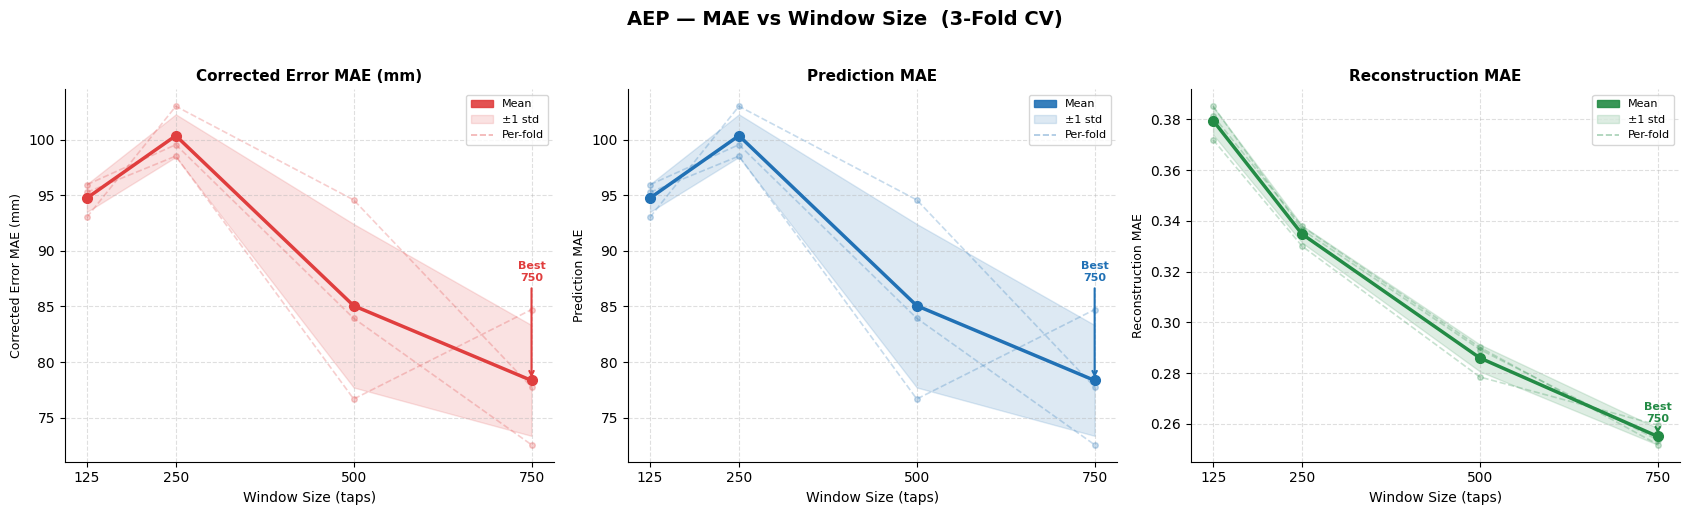

Saved → aep_window_comparison.png

AEP — Best Window per Metric
  Corrected Error MAE (mm)       → Window 750  (mean=78.3402)
  Prediction MAE                 → Window 750  (mean=78.3402)
  Reconstruction MAE             → Window 750  (mean=0.2550)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# Run this cell AFTER the CV script has finished.
# Requires `all_results` dict in memory.
# Works for both AEP and CAIRN — just change TITLE below.
# ============================================================

TITLE    = "AEP"         
N_SPLITS = 3              # must match what was used during training

# ------------------------------------------------------------
# Aggregate means + stds + per-fold values
# ------------------------------------------------------------
window_sizes = list(all_results.keys())

metrics = {
    'corr_mae' : {'label': 'Corrected Error MAE (mm)', 'color': '#e03e3e'},
    'pred_mae'  : {'label': 'Prediction MAE',           'color': '#2171b5'},
    'recon_mae' : {'label': 'Reconstruction MAE',        'color': '#238b45'},
}

summary = {}
for key in metrics:
    summary[key] = {
        'means' : [np.mean([f[key] for f in all_results[ws]]) for ws in window_sizes],
        'stds'  : [np.std( [f[key] for f in all_results[ws]]) for ws in window_sizes],
        'folds' : [[all_results[ws][i][key] for ws in window_sizes] for i in range(N_SPLITS)],
    }

# ------------------------------------------------------------
# Plot — 3 subplots side by side
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'{TITLE} — MAE vs Window Size  ({N_SPLITS}-Fold CV)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (key, cfg) in zip(axes, metrics.items()):
    means  = summary[key]['means']
    stds   = summary[key]['stds']
    color  = cfg['color']

    # ---- per-fold thin lines ----
    for fold_vals in summary[key]['folds']:
        ax.plot(window_sizes, fold_vals,
                color=color, alpha=0.25, linewidth=1.2,
                linestyle='--', marker='o', markersize=4)

    # ---- mean line with shaded ±1 std band ----
    means_arr = np.array(means)
    stds_arr  = np.array(stds)
    ax.plot(window_sizes, means_arr,
            color=color, linewidth=2.5, marker='o', markersize=7,
            label='Mean', zorder=5)
    ax.fill_between(window_sizes,
                    means_arr - stds_arr,
                    means_arr + stds_arr,
                    color=color, alpha=0.15, label='±1 std')

    # ---- mark the best (minimum mean) window ----
    best_idx = int(np.argmin(means_arr))
    best_ws  = window_sizes[best_idx]
    best_val = means_arr[best_idx]
    ax.annotate(f'Best\n{best_ws}',
                xy=(best_ws, best_val),
                xytext=(best_ws, best_val + stds_arr[best_idx] * 1.8),
                fontsize=8, ha='center', color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    # ---- formatting ----
    ax.set_title(cfg['label'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Window Size (taps)', fontsize=10)
    ax.set_ylabel(cfg['label'], fontsize=9)
    ax.set_xticks(window_sizes)
    ax.set_xticklabels([str(w) for w in window_sizes])
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    mean_patch = mpatches.Patch(color=color, alpha=0.9,  label='Mean')
    std_patch  = mpatches.Patch(color=color, alpha=0.15, label='±1 std')
    fold_line  = plt.Line2D([0], [0], color=color, alpha=0.4,
                            linestyle='--', linewidth=1.2, label='Per-fold')
    ax.legend(handles=[mean_patch, std_patch, fold_line], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(f'{TITLE.lower()}_window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {TITLE.lower()}_window_comparison.png")

# ------------------------------------------------------------
# Quick best-window summary
# ------------------------------------------------------------
print(f"\n{'='*50}")
print(f"{TITLE} — Best Window per Metric")
print(f"{'='*50}")
for key, cfg in metrics.items():
    means   = summary[key]['means']
    best_ws = window_sizes[int(np.argmin(means))]
    best_v  = min(means)
    print(f"  {cfg['label']:<30} → Window {best_ws}  (mean={best_v:.4f})")



# 📊 CAIRN (OOM-Safe) — Multi-Window Cross-Validation Study

## 🎯 Objective

Due to the high computational cost of full **Hyperparameter Optimization (HPO)**, a **lightweight and memory-safe variant of CAIRN** was designed to:

* Avoid GPU Out-Of-Memory (OOM) issues
* Enable **faster experimentation**
* Study the effect of **CIR window size** on performance
* Maintain reasonable predictive accuracy

---

## ⚡ Key Idea

Instead of tuning architecture extensively, we fix a **compact model** and vary only:

> 📌 **Window size around `fpindex`**

This isolates the impact of **temporal context in CIR signals**.

---

## 🧠 Model: CAIRN (OOM-Safe Variant)

### Architecture Highlights

* **Input:** CIR window `(window_size, 2)` (real + imaginary)
* **Downsampling:** Reduces sequence length → lowers memory
* **Residual CNN blocks:** Capture local CIR structure
* **Lightweight Transformer Attention:**

  * Applied after downsampling
  * Prevents quadratic memory explosion
* **Prediction Head:** Fully connected layers for error regression

### Key Design Choices

| Component       | Design              |
| --------------- | ------------------- |
| Downsampling    | 750 → 375 → 188     |
| Attention       | 2 heads (small)     |
| Mixed Precision | Enabled (`float16`) |
| No Decoder      | Faster training     |
| Loss            | MAE                 |

---

## 🔄 Data Processing

### CIR Alignment

* Convert complex CIR → real & imaginary channels
* Align around:

[
fpindex = \left\lfloor \frac{\text{raw fpindex}}{64} \right\rfloor
]

* Extract window:

[
[fpindex - w/2,; fpindex + w/2]
]

* Apply zero-padding if needed

---

## 🧪 Experiment Setup

### Window Sizes Tested

```python
WINDOW_SIZES = [125, 250, 500, 750]
```

### Cross Validation

* **3-Fold CV**
* Shuffle enabled
* Split:

  * 80% → train
  * 20% → validation (from train)

---

## ⚙️ Training Strategy

### Batch Size (OOM-safe)

| Window | Batch Size |
| ------ | ---------- |
| 125    | 128        |
| 250    | 64         |
| 500    | 32         |
| 750    | 8          |

### Optimization

* Optimizer: Adam (lr = 0.001)
* Loss: MAE
* Callbacks:

  * EarlyStopping (patience=15)
  * ReduceLROnPlateau

---

## 📈 Evaluation Metrics

For each fold:

* **Prediction MAE**
* **Original Error MAE**
* **Corrected Error MAE**

[
\text{Corrected Error} = y_{\text{true}} - y_{\text{pred}}
]

---

## 📊 Visualization

Two plots are generated:

### 1. Prediction MAE vs Window Size

### 2. Corrected Error MAE vs Window Size

Each plot shows:

* Mean performance
* ±1 standard deviation
* Individual fold curves
* Best window annotation

---

## 🏆 Result Summary

The script prints:

```
Window | Pred MAE | Orig MAE | Corr MAE
```

And identifies:

> ✅ **Best window size per metric**

---

## 🔍 Key Observations (What This Experiment Reveals)

### 1. Trade-off: Context vs Noise

* Small window → insufficient CIR information
* Large window → includes noise/multipath clutter

👉 Optimal window balances both

---

### 2. Downsampling is Critical

Without it:

* Attention → O(N²) memory
* Causes OOM

With it:

* Efficient training
* Stable GPU usage

---

### 3. Lightweight Model ≠ Weak Model

Even with:

* Reduced depth
* No reconstruction head

👉 Model still learns meaningful corrections

---

### 4. Practical Insight

This setup is ideal when:

* GPU memory is limited
* Quick experimentation is needed
* You want **design insights before full HPO**

---

## 🚀 Why This Approach Matters

Compared to full HPO:

| Aspect        | Full HPO  | This Approach |
| ------------- | --------- | ------------- |
| Time          | Very high | Low           |
| Memory        | High      | Safe          |
| Flexibility   | High      | Moderate      |
| Insight speed | Slow      | Fast          |

---



In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import gc
import warnings
warnings.filterwarnings('ignore')

tf.keras.mixed_precision.set_global_policy('mixed_float16')
tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# 1. parse_and_align
# ------------------------------------------------------------
def parse_and_align_fast(df, window_size=750):
    half     = window_size // 2
    cir_cols = [f'CIR{i}' for i in range(1016)]
    n        = len(df)

    cir_real = df[cir_cols].applymap(lambda v: complex(v).real).values.astype(np.float32)
    cir_imag = df[cir_cols].applymap(lambda v: complex(v).imag).values.astype(np.float32)
    cir_all  = np.stack([cir_real, cir_imag], axis=-1)

    y  = df['error'].values.astype(np.float32)
    fp = np.clip((df['fpindex'].values // 64).astype(int), 0, 1015)

    print(f"  fpindex //64 : min={fp.min()}, max={fp.max()}, mean={fp.mean():.1f}")

    X = np.zeros((n, window_size, 2), dtype=np.float32)
    for i in range(n):
        start      = fp[i] - half
        end        = fp[i] + half
        sc         = max(0, start)
        ec         = min(1016, end)
        segment    = cir_all[i, sc:ec, :]
        actual_len = segment.shape[0]
        if actual_len < window_size:
            pad_left  = max(0, -start)
            pad_right = window_size - actual_len - pad_left
            segment   = np.pad(segment, ((pad_left, pad_right), (0, 0)), mode='constant')
        X[i] = segment

    return X, y


# ------------------------------------------------------------
# 2. Pool all locations
# ------------------------------------------------------------
print("Parsing and pooling all locations ...")
X_list, y_list = [], []
for loc, df in dfs.items():
    print(f"  Location {loc} ...")
    X_loc, y_loc = parse_and_align_fast(df, window_size=750)
    X_list.append(X_loc)
    y_list.append(y_loc)

X_full = np.concatenate(X_list, axis=0)
y_all  = np.concatenate(y_list, axis=0)
print(f"\nTotal pooled samples : {X_full.shape[0]}")


# ------------------------------------------------------------
# 3. Model
# ------------------------------------------------------------
def residual_conv1d_block(x, filters, kernel_size=5):
    skip = x
    x = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if skip.shape[-1] != filters:
        skip = layers.Conv1D(filters, 1, padding='same', use_bias=False)(skip)
        skip = layers.BatchNormalization()(skip)
    x = layers.Add()([x, skip])
    x = layers.Activation('relu')(x)
    return x


def build_cairn_oom_safe(input_shape, d_model=64):
    inputs = layers.Input(shape=input_shape, name='input_cir')

    # Stem
    x = layers.Conv1D(32, 7, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Strided downsampling: 750 → 375 → 188
    x = layers.Conv1D(32, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv1D(64, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Residual blocks on downsampled sequence
    x = residual_conv1d_block(x, filters=64,      kernel_size=5)
    x = residual_conv1d_block(x, filters=d_model, kernel_size=3)

    # Attention on short sequence (~188 steps) — safe memory-wise
    attn_out = layers.MultiHeadAttention(
        num_heads=2, key_dim=d_model // 2, name='cir_attention'
    )(x, x)
    attn_out = layers.Dropout(0.1)(attn_out)
    x = layers.LayerNormalization()(x + attn_out)

    ff = layers.Dense(d_model * 2, activation='relu')(x)
    ff = layers.Dense(d_model)(ff)
    ff = layers.Dropout(0.1)(ff)
    x  = layers.LayerNormalization()(x + ff)

    # Prediction head
    p = layers.GlobalAveragePooling1D()(x)
    p = layers.Dense(64, activation='relu')(p)
    p = layers.BatchNormalization()(p)
    p = layers.Dropout(0.2)(p)
    p = layers.Dense(32, activation='relu')(p)
    p = layers.BatchNormalization()(p)
    p = layers.Dropout(0.1)(p)
    p = layers.Dense(16, activation='relu')(p)
    prediction = layers.Dense(1, name='prediction', dtype='float32')(p)

    return Model(inputs=inputs, outputs=prediction, name=f'CAIRN_safe_w{input_shape[0]}')


# ------------------------------------------------------------
# 4. Multi-window 3-Fold CV
# ------------------------------------------------------------
WINDOW_SIZES = [125, 250, 500, 750]
N_SPLITS     = 3
kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Conservative batch per window size
BATCH_MAP = {125: 128, 250: 64, 500: 32, 750: 8}

all_results = {}

for window_size in WINDOW_SIZES:
    half  = window_size // 2
    BATCH = BATCH_MAP[window_size]

    print(f"\n{'='*65}")
    print(f"  WINDOW SIZE = {window_size}  (±{half} around fpindex) | batch={BATCH}")
    print(f"{'='*65}")

    centre = 750 // 2
    start  = centre - half
    X_win  = X_full[:, start:start + window_size, :]
    assert X_win.shape[1] == window_size, f"Slice mismatch: got {X_win.shape[1]}"

    fold_results = []

    for fold, (train_val_idx, test_idx) in enumerate(kf.split(X_win)):
        print(f"\n  --- Fold {fold+1}/{N_SPLITS} | window={window_size} ---")

        X_tv, X_test = X_win[train_val_idx], X_win[test_idx]
        y_tv, y_test = y_all[train_val_idx], y_all[test_idx]

        n_val          = int(len(X_tv) * 0.2)
        X_train, X_val = X_tv[n_val:], X_tv[:n_val]
        y_train, y_val = y_tv[n_val:], y_tv[:n_val]

        print(f"    Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

        # Normalize
        mean      = X_train.mean(axis=(0, 1), keepdims=True)
        std       = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8
        X_train_n = (X_train - mean) / std
        X_val_n   = (X_val   - mean) / std
        X_test_n  = (X_test  - mean) / std

        def make_dataset(X, y, shuffle=False):
            ds = tf.data.Dataset.from_tensor_slices((X, y))
            if shuffle:
                ds = ds.shuffle(buffer_size=2048, seed=42)
            return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

        train_ds = make_dataset(X_train_n, y_train, shuffle=True)
        val_ds   = make_dataset(X_val_n,   y_val)
        test_ds  = make_dataset(X_test_n,  y_test)

        # Clear GPU memory before each fold
        gc.collect()
        tf.keras.backend.clear_session()

        model = build_cairn_oom_safe(input_shape=(window_size, 2))
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='mae',
            metrics=['mae']
        )

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                              min_lr=1e-5, verbose=0)
        ]

        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=150,
            callbacks=callbacks,
            verbose=1
        )

        pred_mae  = model.evaluate(test_ds, verbose=0)[1]
        y_pred    = model.predict(test_ds, verbose=0).flatten()
        new_error = y_test - y_pred
        orig_mae  = np.abs(y_test).mean()
        corr_mae  = np.abs(new_error).mean()

        print(f"    Pred MAE={pred_mae:.3f} | Orig={orig_mae:.3f} mm | Corr={corr_mae:.3f} mm")

        fold_results.append({
            'fold':     fold + 1,
            'pred_mae': pred_mae,
            'orig_mae': orig_mae,
            'corr_mae': corr_mae,
        })

    all_results[window_size] = fold_results


# ------------------------------------------------------------
# 5. Summary table
# ------------------------------------------------------------
print(f"\n{'='*60}")
print("CAIRN (OOM-safe) — Multi-Window 3-Fold CV  |  Summary")
print(f"{'='*60}")
print(f"{'Window':>8} | {'Pred MAE':>12} | {'Orig MAE':>12} | {'Corr MAE':>12}")
print(f"{'-'*60}")

for ws, folds in all_results.items():
    pred     = np.mean([f['pred_mae'] for f in folds])
    orig     = np.mean([f['orig_mae'] for f in folds])
    corr     = np.mean([f['corr_mae'] for f in folds])
    pred_std = np.std( [f['pred_mae'] for f in folds])
    corr_std = np.std( [f['corr_mae'] for f in folds])
    print(f"{ws:>8} | {pred:>6.3f}±{pred_std:.3f} | "
          f"{orig:>10.3f}   | {corr:>6.3f}±{corr_std:.3f}")

Parsing and pooling all locations ...
  Location 1 ...
  fpindex //64 : min=712, max=848, mean=744.5
  Location 2 ...
  fpindex //64 : min=732, max=788, mean=746.0
  Location 3 ...
  fpindex //64 : min=717, max=858, mean=745.8
  Location 4 ...
  fpindex //64 : min=711, max=849, mean=745.2
  Location 5 ...
  fpindex //64 : min=726, max=840, mean=745.8
  Location 6 ...
  fpindex //64 : min=706, max=839, mean=746.2
  Location 7 ...
  fpindex //64 : min=715, max=859, mean=745.2
  Location 8 ...
  fpindex //64 : min=715, max=808, mean=745.2
  Location 9 ...
  fpindex //64 : min=681, max=795, mean=745.7
  Location 10 ...
  fpindex //64 : min=699, max=858, mean=744.8
  Location 11 ...
  fpindex //64 : min=714, max=861, mean=745.7
  Location 12 ...
  fpindex //64 : min=716, max=818, mean=745.7
  Location 13 ...
  fpindex //64 : min=705, max=816, mean=745.9
  Location 14 ...
  fpindex //64 : min=716, max=786, mean=745.0
  Location 15 ...
  fpindex //64 : min=715, max=855, mean=744.6
  Location 

I0000 00:00:1777639982.182014  633880 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 42066 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:34:00.0, compute capability: 8.9


Epoch 1/150


2026-05-01 12:53:09.173096: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a03940284c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-01 12:53:09.173116: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-05-01 12:53:09.298809: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-01 12:53:10.095444: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-05-01 12:53:10.531455: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-01 12:53:10.531509: I external/loca

 63/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 211.3732 - mae: 211.3732 

...

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 205.2600 - mae: 205.2600

2026-05-01 13:09:30.385836: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-01 13:09:33.123239: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-01 13:09:33.123273: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-01 13:09:33.123360: I external/l

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 192.4662 - mae: 192.4662 - val_loss: 168.8899 - val_mae: 168.8899 - learning_rate: 0.0010
Epoch 2/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 181.1604 - mae: 181.1604 - val_loss: 158.2147 - val_mae: 158.2147 - learning_rate: 0.0010
Epoch 3/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 170.8837 - mae: 170.8837 - val_loss: 167.4774 - val_mae: 167.4774 - learning_rate: 0.0010
Epoch 4/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 163.2563 - mae: 163.2563 - val_loss: 136.3954 - val_mae: 136.3954 - learning_rate: 0.0010
Epoch 5/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 156.3998 - mae: 156.3998 - val_loss: 130.9857 - val_mae: 130.9857 - learning_rate: 0.0010
Epoch 6/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 149.1252 - mae: 149.1252 - val_loss: 139.2585 - val_mae: 139.2585 - learning_rate: 0.0010
Epoch 7/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 145.5305 - mae: 145.5305 - va

2026-05-01 13:21:57.121695: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-01 13:21:57.121758: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-01 13:21:57.121777: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-01 13:21:57.121790: I external/l

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 190.2973 - mae: 190.2973 - val_loss: 188.6242 - val_mae: 188.6242 - learning_rate: 0.0010
Epoch 2/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 181.8833 - mae: 181.8833 - val_loss: 155.1592 - val_mae: 155.1592 - learning_rate: 0.0010
Epoch 3/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 175.1992 - mae: 175.1992 - val_loss: 324.6120 - val_mae: 324.6120 - learning_rate: 0.0010
Epoch 4/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 167.4422 - mae: 167.4422 - val_loss: 173.6947 - val_mae: 173.6947 - learning_rate: 0.0010
Epoch 5/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 163.4658 - mae: 163.4658 - val_loss: 144.1885 - val_mae: 144.1885 - learning_rate: 0.0010
Epoch 6/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 157.7225 - mae: 157.7225 - val_loss: 146.6068 - val_mae: 146.6068 - learning_rate: 0.0010
Epoch 7/150
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 152.0926 - mae: 152.0926 - val

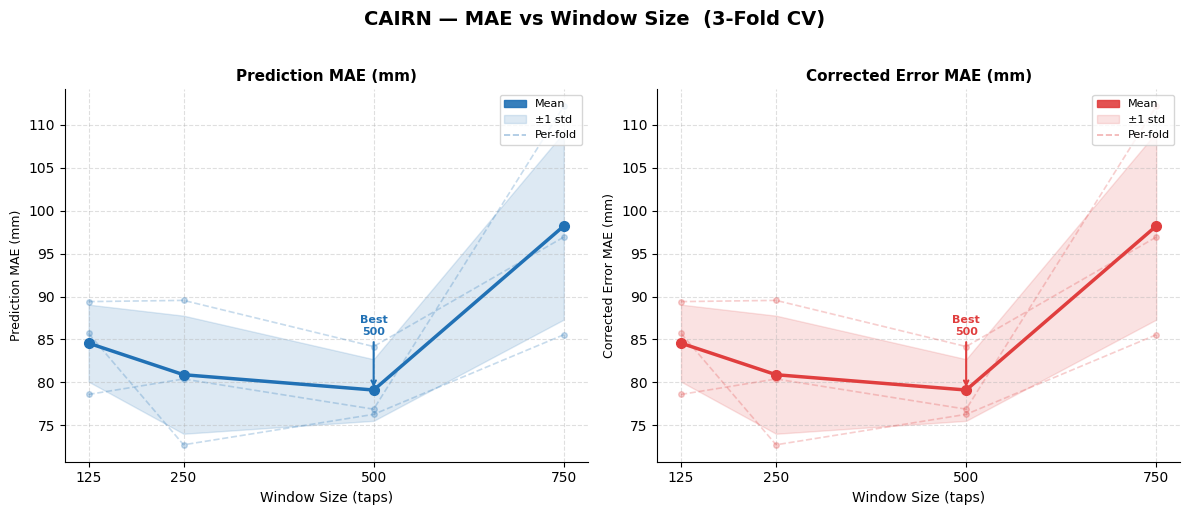

Saved → cairn_window_comparison.png

CAIRN — Best Window per Metric
  Prediction MAE (mm)                 → Window 500  (mean=79.1142)
  Corrected Error MAE (mm)            → Window 500  (mean=79.1142)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TITLE    = "CAIRN"
N_SPLITS = 3

window_sizes = list(all_results.keys())

# ← removed recon_mae (no reconstruction head in fast model)
metrics = {
    'pred_mae' : {'label': 'Prediction MAE (mm)',      'color': '#2171b5'},
    'corr_mae' : {'label': 'Corrected Error MAE (mm)', 'color': '#e03e3e'},
}

summary = {}
for key in metrics:
    summary[key] = {
        'means' : [np.mean([f[key] for f in all_results[ws]]) for ws in window_sizes],
        'stds'  : [np.std( [f[key] for f in all_results[ws]]) for ws in window_sizes],
        'folds' : [[all_results[ws][i][key] for ws in window_sizes] for i in range(N_SPLITS)],
    }

# ← 1x2 subplots instead of 1x3
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'{TITLE} — MAE vs Window Size  ({N_SPLITS}-Fold CV)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (key, cfg) in zip(axes, metrics.items()):
    means  = np.array(summary[key]['means'])
    stds   = np.array(summary[key]['stds'])
    color  = cfg['color']

    for fold_vals in summary[key]['folds']:
        ax.plot(window_sizes, fold_vals,
                color=color, alpha=0.25, linewidth=1.2,
                linestyle='--', marker='o', markersize=4)

    ax.plot(window_sizes, means,
            color=color, linewidth=2.5, marker='o', markersize=7,
            label='Mean', zorder=5)
    ax.fill_between(window_sizes,
                    means - stds,
                    means + stds,
                    color=color, alpha=0.15, label='±1 std')

    best_idx = int(np.argmin(means))
    best_ws  = window_sizes[best_idx]
    best_val = means[best_idx]
    ax.annotate(f'Best\n{best_ws}',
                xy=(best_ws, best_val),
                xytext=(best_ws, best_val + stds[best_idx] * 1.8),
                fontsize=8, ha='center', color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    ax.set_title(cfg['label'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Window Size (taps)', fontsize=10)
    ax.set_ylabel(cfg['label'], fontsize=9)
    ax.set_xticks(window_sizes)
    ax.set_xticklabels([str(w) for w in window_sizes])
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    mean_patch = mpatches.Patch(color=color, alpha=0.9,  label='Mean')
    std_patch  = mpatches.Patch(color=color, alpha=0.15, label='±1 std')
    fold_line  = plt.Line2D([0], [0], color=color, alpha=0.4,
                            linestyle='--', linewidth=1.2, label='Per-fold')
    ax.legend(handles=[mean_patch, std_patch, fold_line], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(f'{TITLE.lower()}_window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {TITLE.lower()}_window_comparison.png")

print(f"\n{'='*50}")
print(f"{TITLE} — Best Window per Metric")
print(f"{'='*50}")
for key, cfg in metrics.items():
    best_ws = window_sizes[int(np.argmin(summary[key]['means']))]
    best_v  = min(summary[key]['means'])
    print(f"  {cfg['label']:<35} → Window {best_ws}  (mean={best_v:.4f})")